In [20]:
import os
import re
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch import nn, optim
from torch.nn import functional as F
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch.optim as optim

# cuda setup
device = torch.device("cuda")


In [21]:


# Dimensiones de la imagen
img_width, img_height = 64, 64

# Perfiles y acciones posibles
perfiles = ['front', 'left', 'right']
acciones = sorted(os.listdir("pruebas modelos/Sprites/frames"))  # Asegurar consistencia
num_acciones = len(acciones)  # Debe ser 3
num_perfiles = len(perfiles)  # Debe ser 3
num_movimientos = 8  # Movimientos 0-7

# Expresión regular para extraer el perfil y el número de movimiento
patron_nombre = re.compile(r'^(front|left|right)_\d+_(\d+)\.(png|jpg|jpeg)$')

class SpritesDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = torch.tensor(self.labels[idx], dtype=torch.long)  # Convertir a entero
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

# Listar rutas y etiquetas
ruta_base = "pruebas modelos/Sprites/frames"
rutas_imagenes = []
etiquetas = []

for accion_idx, accion in enumerate(acciones):
    ruta_accion = os.path.join(ruta_base, accion)
    
    if os.path.isdir(ruta_accion):
        for archivo in os.listdir(ruta_accion):
            if archivo.endswith(('.png', '.jpg', '.jpeg')):
                match = patron_nombre.match(archivo)
                
                if match:
                    perfil_str, mov_idx = match.groups()[0], int(match.groups()[1])
                    
                    if mov_idx >= num_movimientos:
                        continue  # Si el número de movimiento es inválido, ignorarlo

                    # Obtener índice del perfil
                    perfil_idx = perfiles.index(perfil_str)

                    rutas_imagenes.append(os.path.join(ruta_accion, archivo))

                    # Etiqueta única: acción * 24 + perfil * 8 + movimiento
                    etiqueta = (accion_idx * num_perfiles * num_movimientos) + (perfil_idx * num_movimientos) + mov_idx
                    etiquetas.append(etiqueta)

# Convertir listas a numpy arrays
rutas_imagenes = np.array(rutas_imagenes)
etiquetas = np.array(etiquetas, dtype=np.int64)  # Convertir etiquetas a enteros

# Dividir en entrenamiento y prueba
rutas_train, rutas_test, etiquetas_train, etiquetas_test = train_test_split(
    rutas_imagenes, etiquetas, test_size=0.2, random_state=42
)

# Transformaciones para las imágenes
transform = transforms.Compose([
    transforms.Resize((img_width, img_height)),
    transforms.ToTensor()
])

# Crear datasets y dataloaders
train_dataset = SpritesDataset(rutas_train, etiquetas_train, transform=transform)
test_dataset = SpritesDataset(rutas_test, etiquetas_test, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Número total de clases ahora es 72 (3 * 3 * 8)
num_classes = 72  

print(f"Total de imágenes: {len(etiquetas)}")
print(f"Total de clases: {num_classes}")


Total de imágenes: 93312
Total de clases: 72


## VAE

In [5]:

# Hiperparámetros
batch_size = 32
latent_size = 20
epochs = 50
feature_size = img_width * img_height * 3  # 64x64x3


# Definición del modelo VAE
class VAE(nn.Module):
    def __init__(self, feature_size, latent_size):
        super(VAE, self).__init__()
        self.feature_size = feature_size

        # Encoder
        self.fc1 = nn.Linear(feature_size, 512)
        self.fc21 = nn.Linear(512, latent_size)
        self.fc22 = nn.Linear(512, latent_size)

        # Decoder
        self.fc3 = nn.Linear(latent_size, 512)
        self.fc4 = nn.Linear(512, feature_size)

        self.elu = nn.ELU()
        self.sigmoid = nn.Sigmoid()

    def encode(self, x):
        inputs = torch.cat([x], 1)
        h1 = self.elu(self.fc1(inputs))
        z_mu = self.fc21(h1)
        z_var = self.fc22(h1)
        return z_mu, z_var

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        inputs = torch.cat([z], 1)
        h3 = self.elu(self.fc3(inputs))
        return self.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, self.feature_size))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# Crear el modelo
model = VAE(feature_size, latent_size).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Epoch 1: Train Loss: 1507.8675, BCE: 1451.1026, KLD: 56.7650
Epoch 1: Test Loss: 1401.6174, BCE: 1351.3297, KLD: 50.2878


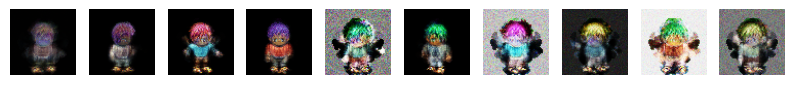

Epoch 2: Train Loss: 1384.1675, BCE: 1335.9957, KLD: 48.1718
Epoch 2: Test Loss: 1376.1597, BCE: 1329.4960, KLD: 46.6637


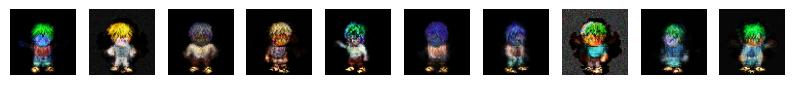

Epoch 3: Train Loss: 1365.0600, BCE: 1318.5139, KLD: 46.5461
Epoch 3: Test Loss: 1365.5793, BCE: 1318.4768, KLD: 47.1025


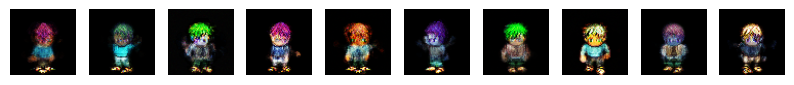

Epoch 4: Train Loss: 1355.6459, BCE: 1309.6987, KLD: 45.9472
Epoch 4: Test Loss: 1355.3182, BCE: 1310.6957, KLD: 44.6225


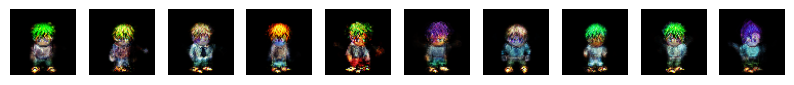

Epoch 5: Train Loss: 1349.9704, BCE: 1304.4267, KLD: 45.5437
Epoch 5: Test Loss: 1352.8951, BCE: 1307.4039, KLD: 45.4912


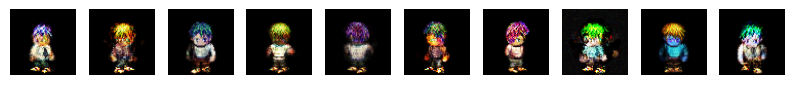

Epoch 6: Train Loss: 1345.7229, BCE: 1300.5311, KLD: 45.1918
Epoch 6: Test Loss: 1348.9305, BCE: 1304.6779, KLD: 44.2526


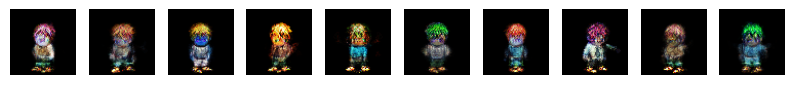

Epoch 7: Train Loss: 1342.4654, BCE: 1297.5855, KLD: 44.8798
Epoch 7: Test Loss: 1343.5860, BCE: 1299.0607, KLD: 44.5253


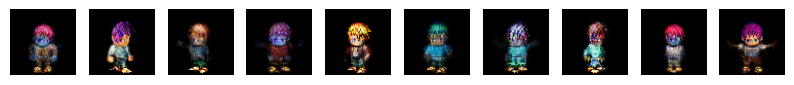

Epoch 8: Train Loss: 1339.7676, BCE: 1295.1542, KLD: 44.6135
Epoch 8: Test Loss: 1340.8309, BCE: 1296.9098, KLD: 43.9211


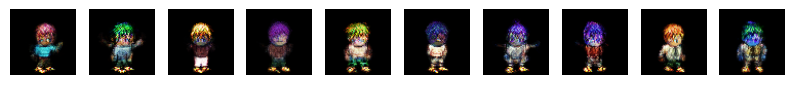

Epoch 9: Train Loss: 1337.7186, BCE: 1293.3726, KLD: 44.3460
Epoch 9: Test Loss: 1340.4280, BCE: 1295.7171, KLD: 44.7109


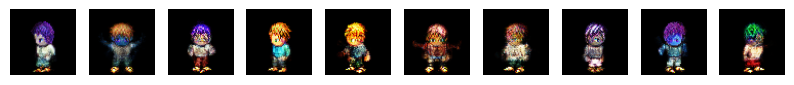

Epoch 10: Train Loss: 1336.0345, BCE: 1291.8834, KLD: 44.1511
Epoch 10: Test Loss: 1339.3180, BCE: 1295.0909, KLD: 44.2271


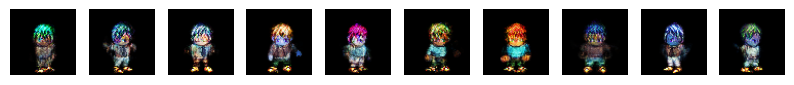

Epoch 11: Train Loss: 1334.4324, BCE: 1290.4993, KLD: 43.9331
Epoch 11: Test Loss: 1335.6425, BCE: 1291.1907, KLD: 44.4518


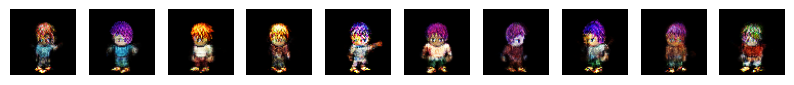

Epoch 12: Train Loss: 1333.1102, BCE: 1289.3699, KLD: 43.7403
Epoch 12: Test Loss: 1337.7939, BCE: 1294.0686, KLD: 43.7253


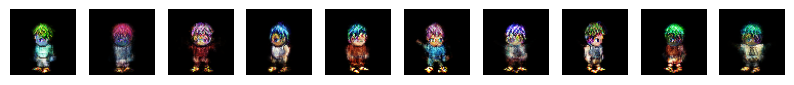

Epoch 13: Train Loss: 1331.7329, BCE: 1288.1993, KLD: 43.5336
Epoch 13: Test Loss: 1336.9436, BCE: 1293.2371, KLD: 43.7065


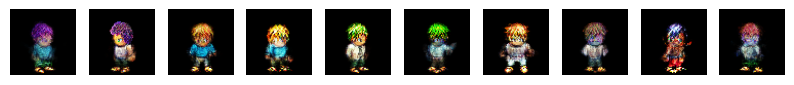

Epoch 14: Train Loss: 1330.7524, BCE: 1287.3671, KLD: 43.3853
Epoch 14: Test Loss: 1335.3998, BCE: 1292.7844, KLD: 42.6153


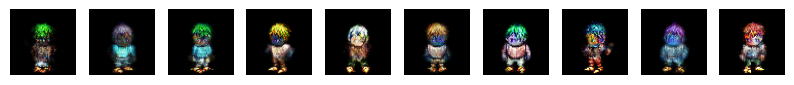

Epoch 15: Train Loss: 1329.5868, BCE: 1286.3608, KLD: 43.2260
Epoch 15: Test Loss: 1331.9004, BCE: 1289.0140, KLD: 42.8864


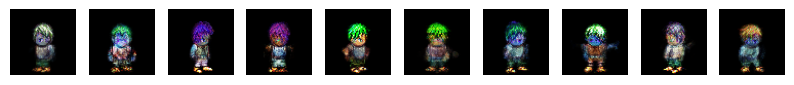

Epoch 16: Train Loss: 1329.1633, BCE: 1286.0575, KLD: 43.1058
Epoch 16: Test Loss: 1336.2688, BCE: 1293.1051, KLD: 43.1637


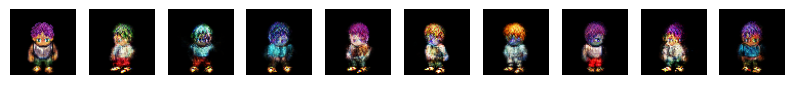

Epoch 17: Train Loss: 1328.1837, BCE: 1285.2206, KLD: 42.9631
Epoch 17: Test Loss: 1332.6862, BCE: 1289.5809, KLD: 43.1053


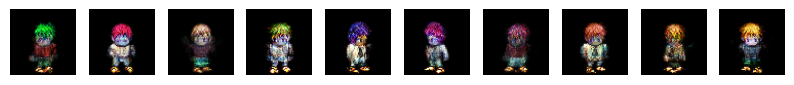

Epoch 18: Train Loss: 1327.4705, BCE: 1284.6101, KLD: 42.8604
Epoch 18: Test Loss: 1329.9408, BCE: 1288.8150, KLD: 41.1259


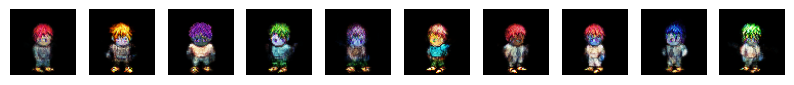

Epoch 19: Train Loss: 1326.7628, BCE: 1284.0486, KLD: 42.7142
Epoch 19: Test Loss: 1330.8931, BCE: 1288.5150, KLD: 42.3780


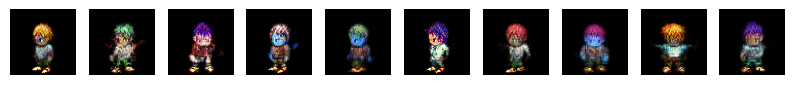

Epoch 20: Train Loss: 1325.9722, BCE: 1283.3535, KLD: 42.6187
Epoch 20: Test Loss: 1329.9179, BCE: 1288.1650, KLD: 41.7529


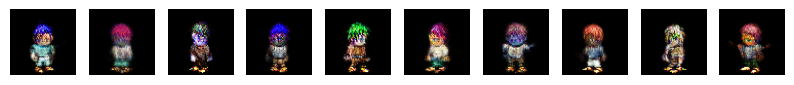

Epoch 21: Train Loss: 1325.4761, BCE: 1282.9653, KLD: 42.5108
Epoch 21: Test Loss: 1329.6610, BCE: 1287.8229, KLD: 41.8380


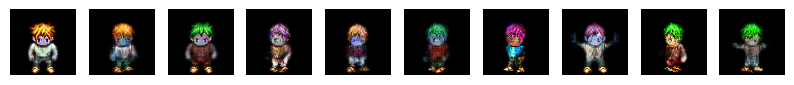

Epoch 22: Train Loss: 1325.0592, BCE: 1282.6435, KLD: 42.4157
Epoch 22: Test Loss: 1326.0452, BCE: 1283.6750, KLD: 42.3703


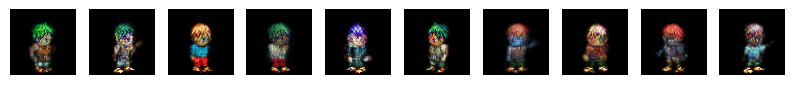

Epoch 23: Train Loss: 1324.5007, BCE: 1282.1943, KLD: 42.3064
Epoch 23: Test Loss: 1328.0970, BCE: 1286.0951, KLD: 42.0019


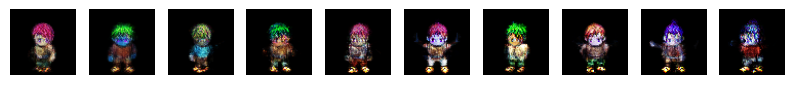

Epoch 24: Train Loss: 1324.0442, BCE: 1281.8154, KLD: 42.2288
Epoch 24: Test Loss: 1326.6372, BCE: 1284.1072, KLD: 42.5300


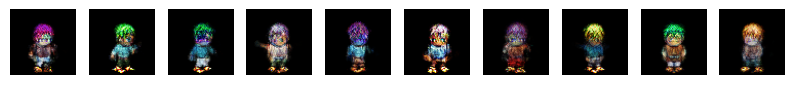

Epoch 25: Train Loss: 1323.6605, BCE: 1281.5021, KLD: 42.1584
Epoch 25: Test Loss: 1326.1221, BCE: 1282.9328, KLD: 43.1893


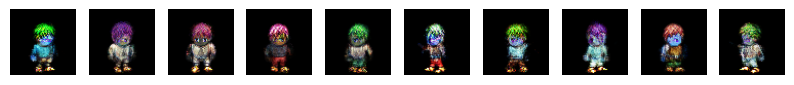

Epoch 26: Train Loss: 1323.0178, BCE: 1280.9552, KLD: 42.0626
Epoch 26: Test Loss: 1328.8231, BCE: 1286.5113, KLD: 42.3118


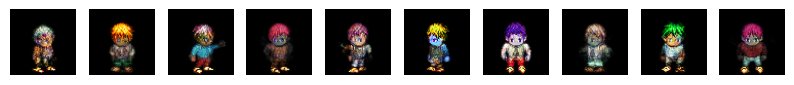

Epoch 27: Train Loss: 1322.7336, BCE: 1280.7682, KLD: 41.9655
Epoch 27: Test Loss: 1325.8570, BCE: 1284.2414, KLD: 41.6156


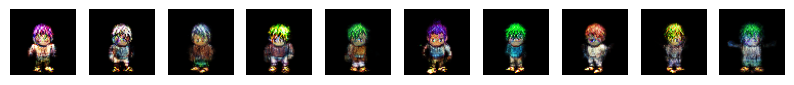

Epoch 28: Train Loss: 1322.3142, BCE: 1280.4457, KLD: 41.8685
Epoch 28: Test Loss: 1323.3511, BCE: 1282.5700, KLD: 40.7811


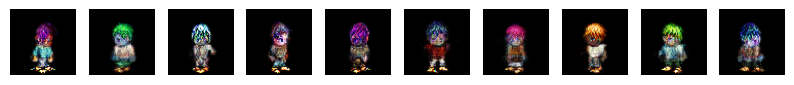

Epoch 29: Train Loss: 1322.1113, BCE: 1280.2582, KLD: 41.8531
Epoch 29: Test Loss: 1327.3395, BCE: 1286.1468, KLD: 41.1927


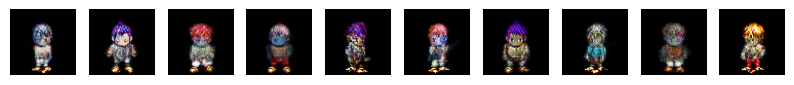

Epoch 30: Train Loss: 1321.6373, BCE: 1279.8765, KLD: 41.7609
Epoch 30: Test Loss: 1323.9639, BCE: 1282.5616, KLD: 41.4022


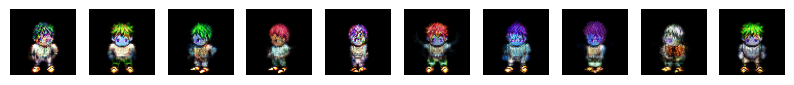

Epoch 31: Train Loss: 1321.3843, BCE: 1279.6675, KLD: 41.7168
Epoch 31: Test Loss: 1323.9221, BCE: 1282.7115, KLD: 41.2107


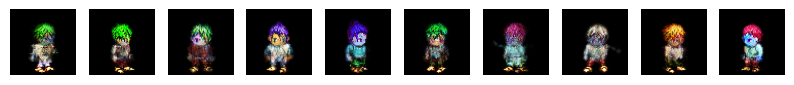

Epoch 32: Train Loss: 1321.1146, BCE: 1279.4346, KLD: 41.6800
Epoch 32: Test Loss: 1323.3369, BCE: 1282.7275, KLD: 40.6094


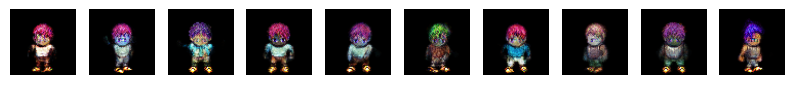

Epoch 33: Train Loss: 1320.8460, BCE: 1279.2782, KLD: 41.5678
Epoch 33: Test Loss: 1324.7392, BCE: 1281.3336, KLD: 43.4056


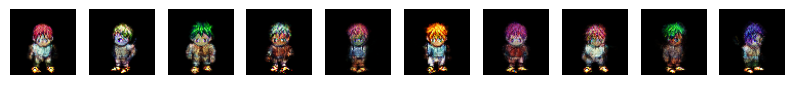

Epoch 34: Train Loss: 1320.3734, BCE: 1278.8606, KLD: 41.5128
Epoch 34: Test Loss: 1323.2748, BCE: 1282.9714, KLD: 40.3034


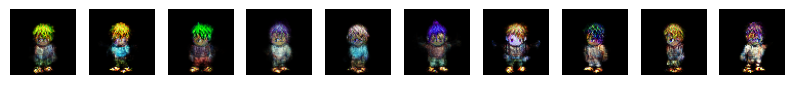

Epoch 35: Train Loss: 1320.2053, BCE: 1278.7597, KLD: 41.4456
Epoch 35: Test Loss: 1324.8042, BCE: 1283.1270, KLD: 41.6772


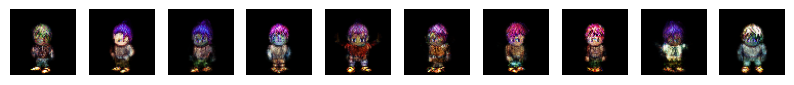

Epoch 36: Train Loss: 1319.8932, BCE: 1278.4892, KLD: 41.4040
Epoch 36: Test Loss: 1325.2095, BCE: 1283.9137, KLD: 41.2958


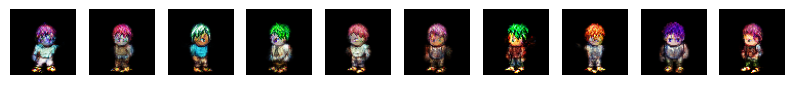

Epoch 37: Train Loss: 1319.7626, BCE: 1278.4149, KLD: 41.3478
Epoch 37: Test Loss: 1322.4075, BCE: 1281.5668, KLD: 40.8406


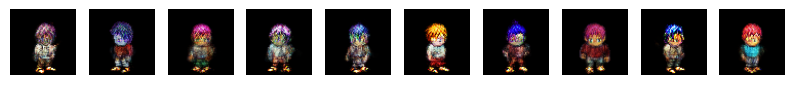

Epoch 38: Train Loss: 1319.3594, BCE: 1278.0481, KLD: 41.3113
Epoch 38: Test Loss: 1321.9235, BCE: 1280.3966, KLD: 41.5269


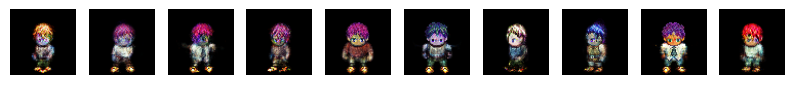

Epoch 39: Train Loss: 1319.3409, BCE: 1278.0962, KLD: 41.2447
Epoch 39: Test Loss: 1326.1983, BCE: 1285.0940, KLD: 41.1043


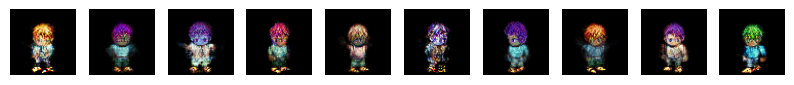

Epoch 40: Train Loss: 1319.1044, BCE: 1277.8962, KLD: 41.2083
Epoch 40: Test Loss: 1321.4826, BCE: 1282.1066, KLD: 39.3760


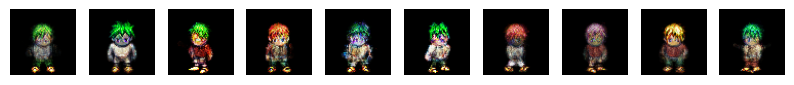

Epoch 41: Train Loss: 1318.9726, BCE: 1277.7988, KLD: 41.1738
Epoch 41: Test Loss: 1320.6290, BCE: 1278.3175, KLD: 42.3115


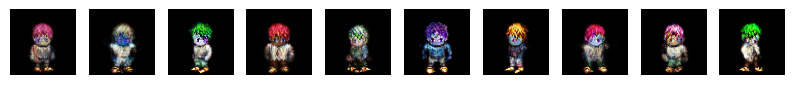

Epoch 42: Train Loss: 1318.5913, BCE: 1277.4828, KLD: 41.1085
Epoch 42: Test Loss: 1324.0023, BCE: 1282.2313, KLD: 41.7709


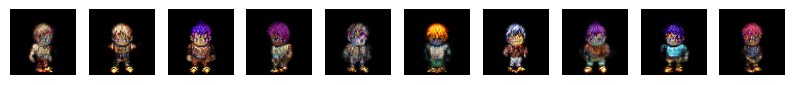

Epoch 43: Train Loss: 1318.4551, BCE: 1277.3954, KLD: 41.0597
Epoch 43: Test Loss: 1324.3450, BCE: 1283.2465, KLD: 41.0986


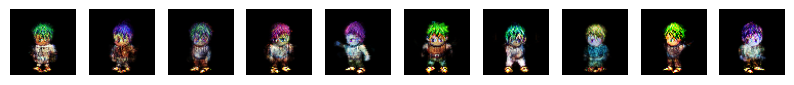

Epoch 44: Train Loss: 1318.4609, BCE: 1277.4010, KLD: 41.0599
Epoch 44: Test Loss: 1319.8072, BCE: 1278.2447, KLD: 41.5625


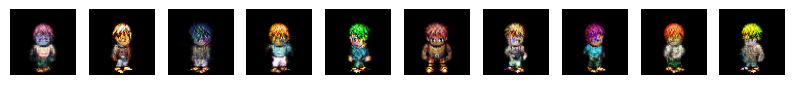

Epoch 45: Train Loss: 1318.0732, BCE: 1277.0683, KLD: 41.0049
Epoch 45: Test Loss: 1319.9503, BCE: 1278.9950, KLD: 40.9553


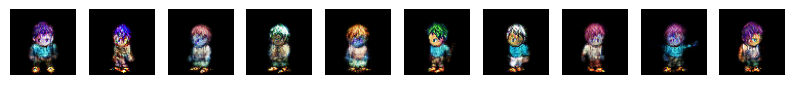

Epoch 46: Train Loss: 1318.1190, BCE: 1277.1335, KLD: 40.9854
Epoch 46: Test Loss: 1321.2192, BCE: 1280.4563, KLD: 40.7630


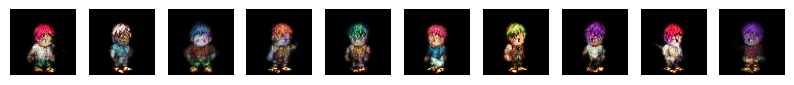

Epoch 47: Train Loss: 1317.7766, BCE: 1276.8593, KLD: 40.9173
Epoch 47: Test Loss: 1320.5726, BCE: 1281.2253, KLD: 39.3474


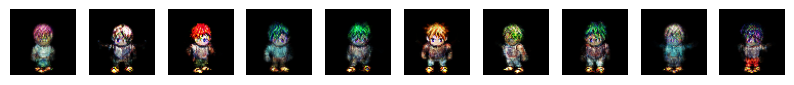

Epoch 48: Train Loss: 1317.6575, BCE: 1276.7664, KLD: 40.8911
Epoch 48: Test Loss: 1323.8598, BCE: 1283.5598, KLD: 40.3000


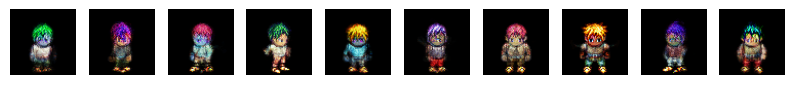

Epoch 49: Train Loss: 1317.4338, BCE: 1276.6253, KLD: 40.8085
Epoch 49: Test Loss: 1320.8574, BCE: 1280.0591, KLD: 40.7983


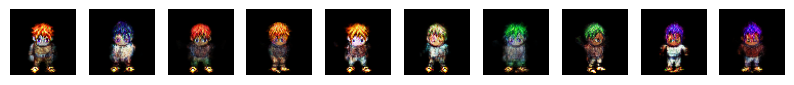

Epoch 50: Train Loss: 1317.3560, BCE: 1276.5365, KLD: 40.8195
Epoch 50: Test Loss: 1322.4013, BCE: 1281.2505, KLD: 41.1508


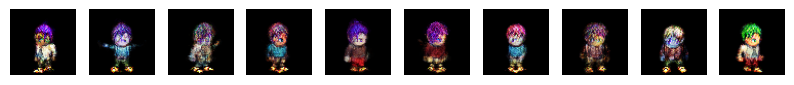

In [6]:


# Almacenar las pérdidas
train_losses = []
test_losses = []

def loss_function(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, feature_size), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())  # Divergencia KL
    return BCE + KLD, BCE, KLD

def train(epoch):
    model.train()
    total_loss = 0
    total_bce = 0
    total_kld = 0

    for batch_idx, (data, labels) in enumerate(train_loader):
        data = data.to(device)

        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss, bce, kld = loss_function(recon_batch, data, mu, logvar)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_bce += bce.item()
        total_kld += kld.item()

    avg_loss = total_loss / len(train_loader.dataset)
    avg_bce = total_bce / len(train_loader.dataset)
    avg_kld = total_kld / len(train_loader.dataset)

    train_losses.append((avg_loss, avg_bce, avg_kld))
    print(f"Epoch {epoch}: Train Loss: {avg_loss:.4f}, BCE: {avg_bce:.4f}, KLD: {avg_kld:.4f}")

def test(epoch):
    model.eval()
    total_loss = 0
    total_bce = 0
    total_kld = 0

    with torch.no_grad():
        for (data, labels) in test_loader:
            data = data.to(device)
            recon_batch, mu, logvar = model(data)
            loss, bce, kld = loss_function(recon_batch, data, mu, logvar)

            total_loss += loss.item()
            total_bce += bce.item()
            total_kld += kld.item()

    avg_loss = total_loss / len(test_loader.dataset)
    avg_bce = total_bce / len(test_loader.dataset)
    avg_kld = total_kld / len(test_loader.dataset)

    test_losses.append((avg_loss, avg_bce, avg_kld))
    print(f"Epoch {epoch}: Test Loss: {avg_loss:.4f}, BCE: {avg_bce:.4f}, KLD: {avg_kld:.4f}")

# Entrenamiento
for epoch in range(1, epochs + 1):
    train(epoch)
    test(epoch)
    #Dibujar entre epocas
    with torch.no_grad():
        sample = torch.randn(10, latent_size).to(device)
        sample = model.decode(sample).cpu()
        fig, axes = plt.subplots(1, 10, figsize=(10, 1))
        for j in range(10):
            axes[j].imshow(sample.view(10, 3, 64, 64)[j].permute(1, 2, 0).cpu().numpy())
            axes[j].axis("off")
        plt.show()



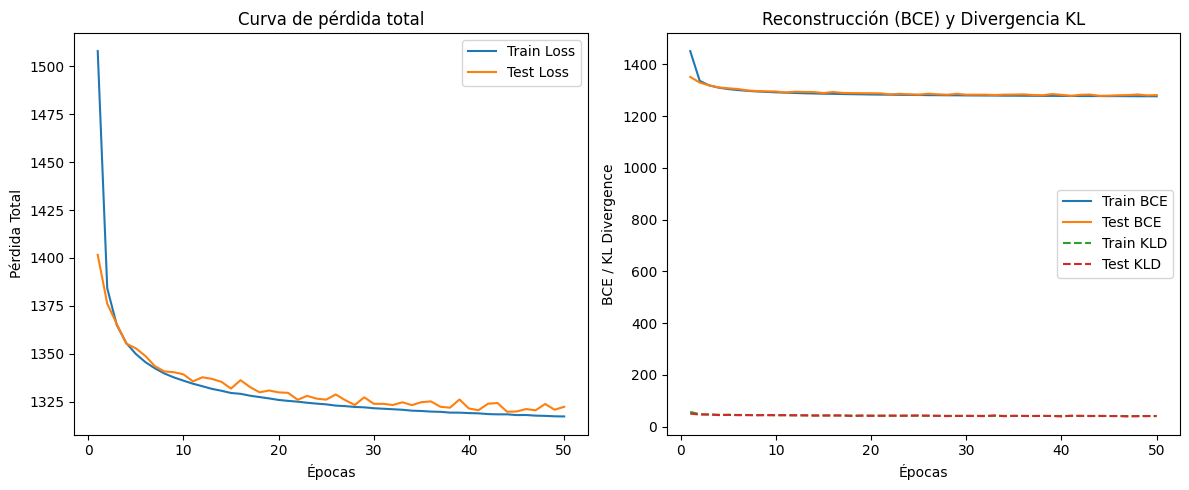

In [7]:
# Graficar curvas de pérdida
epochs_range = range(1, epochs + 1)
train_loss, train_bce, train_kld = zip(*train_losses)
test_loss, test_bce, test_kld = zip(*test_losses)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, label="Train Loss")
plt.plot(epochs_range, test_loss, label="Test Loss")
plt.xlabel("Épocas")
plt.ylabel("Pérdida Total")
plt.legend()
plt.title("Curva de pérdida total")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_bce, label="Train BCE")
plt.plot(epochs_range, test_bce, label="Test BCE")
plt.plot(epochs_range, train_kld, label="Train KLD", linestyle="dashed")
plt.plot(epochs_range, test_kld, label="Test KLD", linestyle="dashed")
plt.xlabel("Épocas")
plt.ylabel("BCE / KL Divergence")
plt.legend()
plt.title("Reconstrucción (BCE) y Divergencia KL")

plt.tight_layout()
plt.show()

Consumo de VRAM: 208.93 MB
Consumo de RAM: 284.00 MB
Tiempo promedio por imagen: 0.0047 segundos


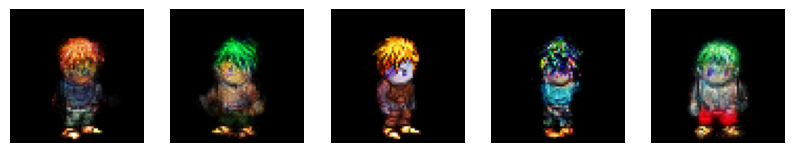

In [10]:
import time

import torch.cuda as cuda



def generate_images_VAE(model, num_samples=5):
    model.eval()  # Modo evaluación
   
    # Medir uso inicial de recursos
    start_time = time.time()
    with torch.no_grad():
        # Generar puntos aleatorios en el espacio latente
        z = torch.randn(num_samples, latent_size).to(device)

        # Decodificar para obtener imágenes
        generated_images = model.decode(z).cpu()
        generated_images = generated_images.view(-1, 3, 64, 64)  # RGB format

    # Medir uso final de recursos
    end_time = time.time()
    if device.type == 'cuda':
        vram_usage = cuda.memory_allocated(device) / (1024 ** 2)  # MB
        print(f"Consumo de VRAM: {vram_usage:.2f} MB")
    
    ram_usage = torch.cuda.memory_reserved(device) / (1024 ** 2)  # MB
    print(f"Consumo de RAM: {ram_usage:.2f} MB")
    # Calcular métricas
    execution_time = (end_time - start_time) / num_samples

    print(f"Tiempo promedio por imagen: {execution_time:.4f} segundos")
    

    # Mostrar las imágenes con la clase
    fig, axes = plt.subplots(1, num_samples, figsize=(num_samples * 2, 2))
    for i in range(num_samples):
        img = generated_images[i].permute(1, 2, 0).numpy()  # Reordenar ejes
        img = (img - img.min()) / (img.max() - img.min())  # Normalizar a [0,1]
        axes[i].imshow(img)
        axes[i].axis('off')

    plt.show()

# Llamar a la función para generar imágenes
generate_images_VAE(model, num_samples=5)



In [12]:
#guardar modelo


import torch

# Asumiendo que 'model' es tu modelo entrenado
PATH = "pruebas modelos/VIU-TFM/modelos guardados/vae_state_dicts.pth" # Nombre del archivo a guardar
torch.save(model.state_dict(), PATH)

PATH = "pruebas modelos/VIU-TFM/modelos guardados/VAE_completo.pth"
torch.save(model, PATH)




## CVAE

In [15]:

# Hiperparámetros
batch_size = 32
latent_size = 20
epochs = 50
feature_size = img_width * img_height * 3  # 64x64x3
num_classes = 72  # 3 acciones * 3 perfiles * 8 movimientos

# Función para generar one-hot encoding
def one_hot(labels, class_size):
    return F.one_hot(labels, class_size).float().to(device)

# Definición del modelo CVAE
class CVAE(nn.Module):
    def __init__(self, feature_size, latent_size, class_size):
        super(CVAE, self).__init__()
        self.feature_size = feature_size
        self.class_size = class_size

        # Encoder
        self.fc1 = nn.Linear(feature_size + class_size, 512)
        self.fc21 = nn.Linear(512, latent_size)
        self.fc22 = nn.Linear(512, latent_size)

        # Decoder
        self.fc3 = nn.Linear(latent_size + class_size, 512)
        self.fc4 = nn.Linear(512, feature_size)

        self.elu = nn.ELU()
        self.sigmoid = nn.Sigmoid()

    def encode(self, x, c):
        inputs = torch.cat([x, c], 1)
        h1 = self.elu(self.fc1(inputs))
        z_mu = self.fc21(h1)
        z_var = self.fc22(h1)
        return z_mu, z_var

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, c):
        inputs = torch.cat([z, c], 1)
        h3 = self.elu(self.fc3(inputs))
        return self.sigmoid(self.fc4(h3))

    def forward(self, x, c):
        mu, logvar = self.encode(x.view(-1, self.feature_size), c)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, c), mu, logvar

# Crear el modelo
model = CVAE(feature_size, latent_size, num_classes).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Epoch 1: Train Loss: 1513.2575, BCE: 1462.4809, KLD: 50.7767
Epoch 1: Test Loss: 1389.1286, BCE: 1347.3336, KLD: 41.7950


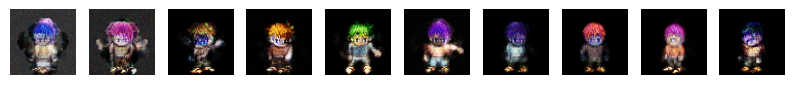

Epoch 2: Train Loss: 1365.6177, BCE: 1326.2473, KLD: 39.3704
Epoch 2: Test Loss: 1354.0613, BCE: 1316.1911, KLD: 37.8702


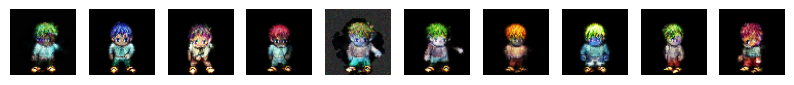

Epoch 3: Train Loss: 1340.8023, BCE: 1305.0498, KLD: 35.7525
Epoch 3: Test Loss: 1336.7366, BCE: 1301.8430, KLD: 34.8935


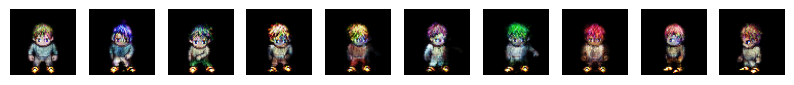

Epoch 4: Train Loss: 1327.6853, BCE: 1294.2554, KLD: 33.4299
Epoch 4: Test Loss: 1327.1158, BCE: 1294.7877, KLD: 32.3281


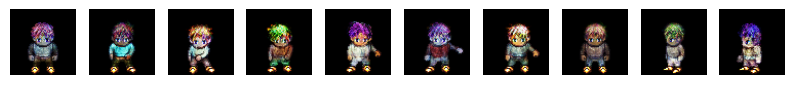

Epoch 5: Train Loss: 1318.9782, BCE: 1287.0442, KLD: 31.9340
Epoch 5: Test Loss: 1318.3356, BCE: 1286.5258, KLD: 31.8097


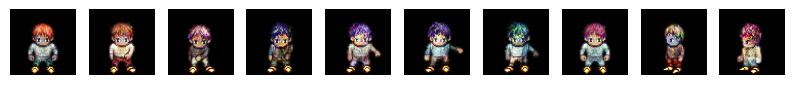

Epoch 6: Train Loss: 1312.4096, BCE: 1281.7950, KLD: 30.6146
Epoch 6: Test Loss: 1315.8350, BCE: 1284.7456, KLD: 31.0894


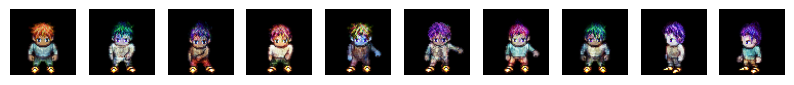

Epoch 7: Train Loss: 1307.4986, BCE: 1278.1554, KLD: 29.3432
Epoch 7: Test Loss: 1308.5688, BCE: 1279.8516, KLD: 28.7173


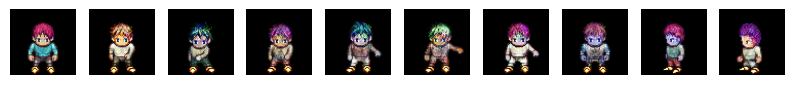

Epoch 8: Train Loss: 1303.0036, BCE: 1275.0774, KLD: 27.9262
Epoch 8: Test Loss: 1304.8349, BCE: 1277.4297, KLD: 27.4052


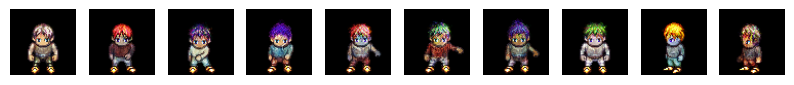

Epoch 9: Train Loss: 1299.3860, BCE: 1272.6206, KLD: 26.7654
Epoch 9: Test Loss: 1300.6649, BCE: 1274.7746, KLD: 25.8903


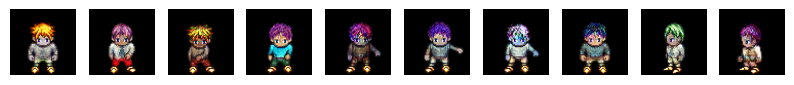

Epoch 10: Train Loss: 1296.4015, BCE: 1270.4174, KLD: 25.9840
Epoch 10: Test Loss: 1297.9220, BCE: 1272.3863, KLD: 25.5357


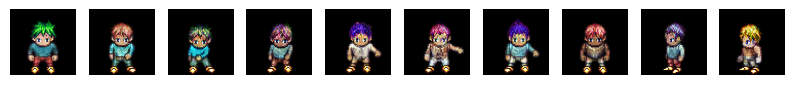

Epoch 11: Train Loss: 1293.9001, BCE: 1268.6486, KLD: 25.2515
Epoch 11: Test Loss: 1295.9504, BCE: 1271.2930, KLD: 24.6574


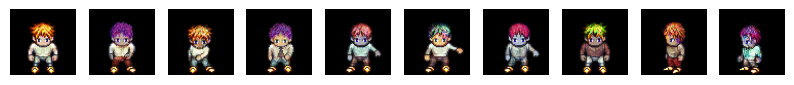

Epoch 12: Train Loss: 1291.8640, BCE: 1267.1286, KLD: 24.7354
Epoch 12: Test Loss: 1293.9111, BCE: 1267.9734, KLD: 25.9377


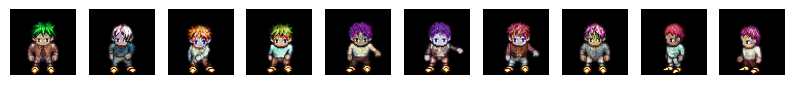

Epoch 13: Train Loss: 1290.1311, BCE: 1265.8846, KLD: 24.2465
Epoch 13: Test Loss: 1292.2748, BCE: 1267.6580, KLD: 24.6167


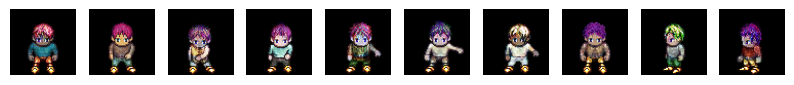

Epoch 14: Train Loss: 1288.5271, BCE: 1264.7268, KLD: 23.8002
Epoch 14: Test Loss: 1292.1204, BCE: 1267.4269, KLD: 24.6935


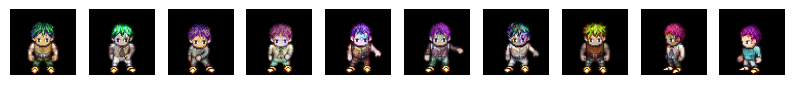

Epoch 15: Train Loss: 1287.3761, BCE: 1263.7699, KLD: 23.6061
Epoch 15: Test Loss: 1290.7185, BCE: 1268.4760, KLD: 22.2426


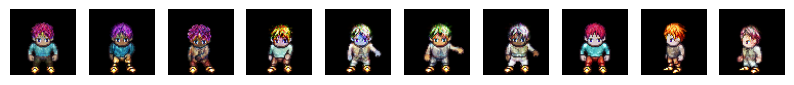

Epoch 16: Train Loss: 1286.6205, BCE: 1263.1450, KLD: 23.4755
Epoch 16: Test Loss: 1288.4962, BCE: 1265.9292, KLD: 22.5670


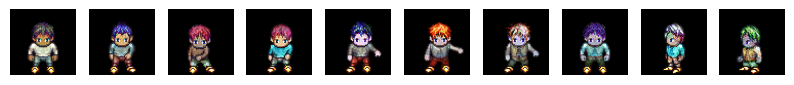

Epoch 17: Train Loss: 1285.8157, BCE: 1262.5378, KLD: 23.2779
Epoch 17: Test Loss: 1289.1583, BCE: 1265.3976, KLD: 23.7607


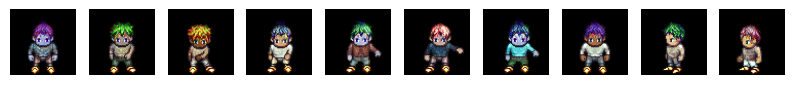

Epoch 18: Train Loss: 1285.0953, BCE: 1261.9642, KLD: 23.1311
Epoch 18: Test Loss: 1288.0913, BCE: 1265.1133, KLD: 22.9780


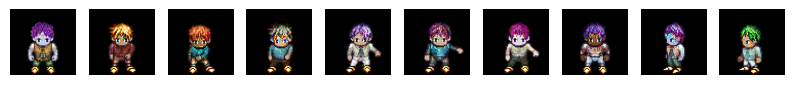

Epoch 19: Train Loss: 1284.5757, BCE: 1261.5751, KLD: 23.0005
Epoch 19: Test Loss: 1288.9601, BCE: 1265.8048, KLD: 23.1554


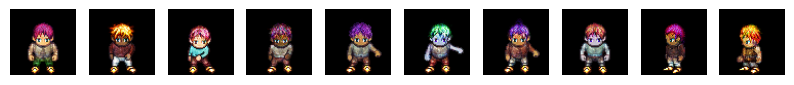

Epoch 20: Train Loss: 1283.9512, BCE: 1261.0800, KLD: 22.8712
Epoch 20: Test Loss: 1286.8814, BCE: 1263.1850, KLD: 23.6964


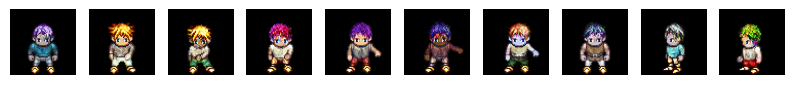

Epoch 21: Train Loss: 1283.5776, BCE: 1260.8104, KLD: 22.7672
Epoch 21: Test Loss: 1287.0575, BCE: 1264.1085, KLD: 22.9490


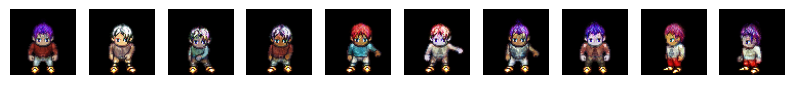

Epoch 22: Train Loss: 1283.0343, BCE: 1260.4475, KLD: 22.5868
Epoch 22: Test Loss: 1286.5671, BCE: 1263.6070, KLD: 22.9601


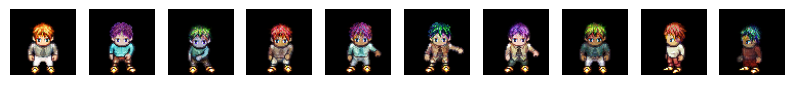

Epoch 23: Train Loss: 1282.5480, BCE: 1260.0867, KLD: 22.4613
Epoch 23: Test Loss: 1285.6825, BCE: 1262.4269, KLD: 23.2556


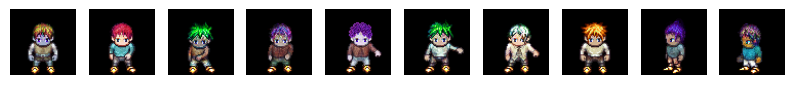

Epoch 24: Train Loss: 1282.2565, BCE: 1259.9110, KLD: 22.3456
Epoch 24: Test Loss: 1285.1700, BCE: 1262.7957, KLD: 22.3743


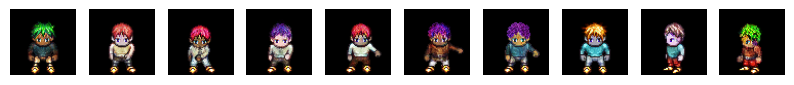

Epoch 25: Train Loss: 1281.7726, BCE: 1259.5895, KLD: 22.1831
Epoch 25: Test Loss: 1284.8382, BCE: 1261.5146, KLD: 23.3236


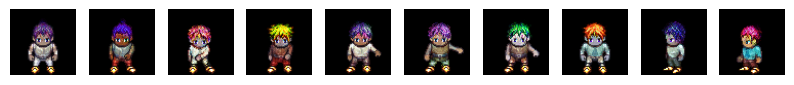

Epoch 26: Train Loss: 1281.3859, BCE: 1259.3433, KLD: 22.0427
Epoch 26: Test Loss: 1284.8234, BCE: 1263.2502, KLD: 21.5732


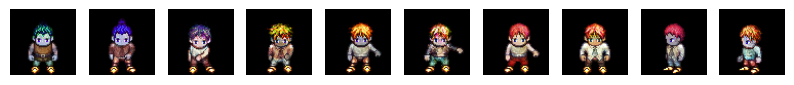

Epoch 27: Train Loss: 1281.0613, BCE: 1259.1401, KLD: 21.9212
Epoch 27: Test Loss: 1284.1611, BCE: 1261.2022, KLD: 22.9589


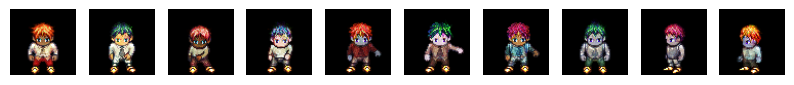

Epoch 28: Train Loss: 1280.6912, BCE: 1258.8779, KLD: 21.8133
Epoch 28: Test Loss: 1284.9852, BCE: 1263.0691, KLD: 21.9160


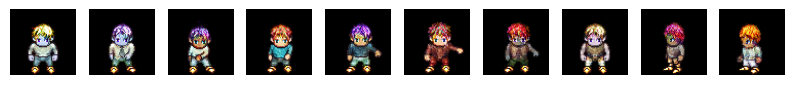

Epoch 29: Train Loss: 1280.4602, BCE: 1258.7313, KLD: 21.7289
Epoch 29: Test Loss: 1283.8337, BCE: 1262.5374, KLD: 21.2963


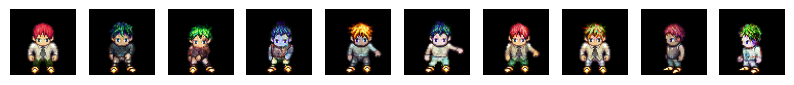

Epoch 30: Train Loss: 1280.0178, BCE: 1258.4793, KLD: 21.5385
Epoch 30: Test Loss: 1282.2632, BCE: 1261.0474, KLD: 21.2158


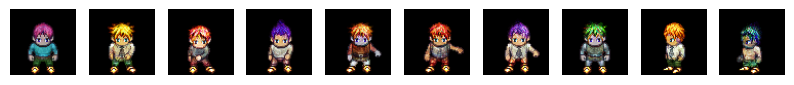

Epoch 31: Train Loss: 1279.6785, BCE: 1258.3194, KLD: 21.3591
Epoch 31: Test Loss: 1283.4660, BCE: 1262.7040, KLD: 20.7620


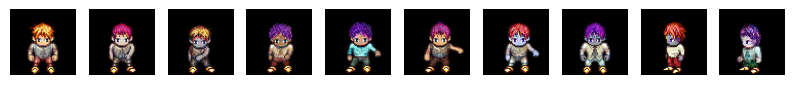

Epoch 32: Train Loss: 1279.3937, BCE: 1258.0938, KLD: 21.2999
Epoch 32: Test Loss: 1282.0931, BCE: 1261.6806, KLD: 20.4126


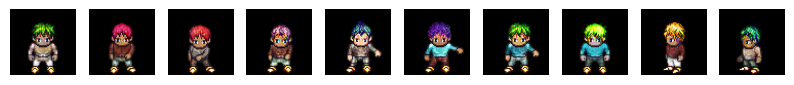

Epoch 33: Train Loss: 1279.1137, BCE: 1257.8960, KLD: 21.2177
Epoch 33: Test Loss: 1281.9582, BCE: 1261.8000, KLD: 20.1582


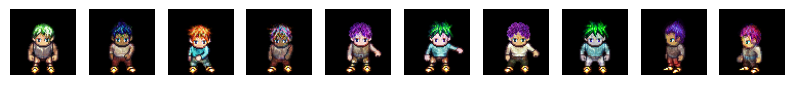

Epoch 34: Train Loss: 1278.8462, BCE: 1257.6841, KLD: 21.1621
Epoch 34: Test Loss: 1281.9920, BCE: 1260.9063, KLD: 21.0857


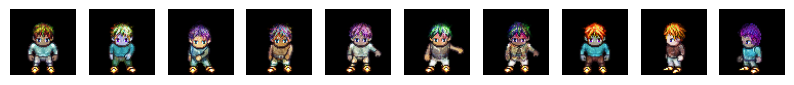

Epoch 35: Train Loss: 1278.6262, BCE: 1257.5571, KLD: 21.0691
Epoch 35: Test Loss: 1282.1344, BCE: 1262.1157, KLD: 20.0187


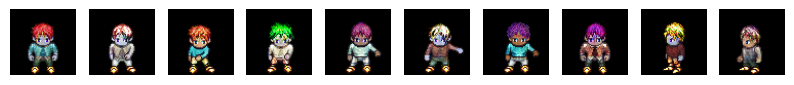

Epoch 36: Train Loss: 1278.4832, BCE: 1257.4399, KLD: 21.0433
Epoch 36: Test Loss: 1281.2263, BCE: 1260.0694, KLD: 21.1569


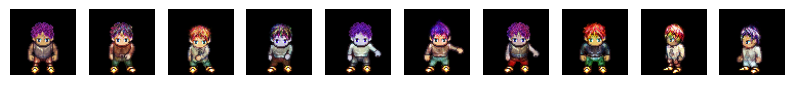

Epoch 37: Train Loss: 1278.1920, BCE: 1257.2346, KLD: 20.9575
Epoch 37: Test Loss: 1280.8665, BCE: 1258.7839, KLD: 22.0826


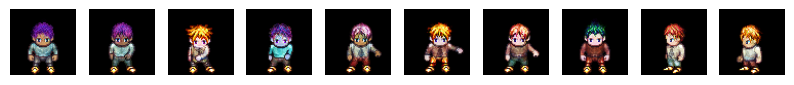

Epoch 38: Train Loss: 1278.0057, BCE: 1257.1236, KLD: 20.8822
Epoch 38: Test Loss: 1281.1395, BCE: 1260.4295, KLD: 20.7100


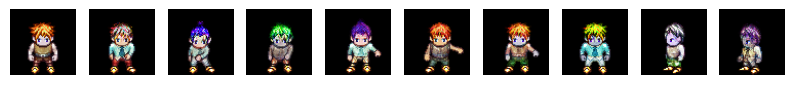

Epoch 39: Train Loss: 1277.8567, BCE: 1257.0298, KLD: 20.8269
Epoch 39: Test Loss: 1281.4430, BCE: 1260.3382, KLD: 21.1047


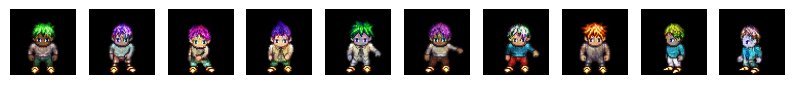

Epoch 40: Train Loss: 1277.7827, BCE: 1256.9634, KLD: 20.8193
Epoch 40: Test Loss: 1281.5198, BCE: 1259.9368, KLD: 21.5830


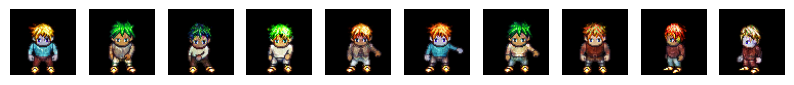

Epoch 41: Train Loss: 1277.6042, BCE: 1256.8261, KLD: 20.7782
Epoch 41: Test Loss: 1280.6377, BCE: 1259.1300, KLD: 21.5077


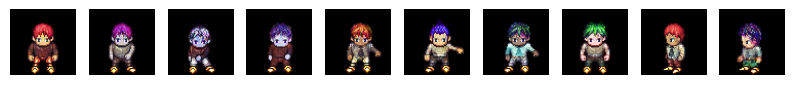

Epoch 42: Train Loss: 1277.4740, BCE: 1256.7476, KLD: 20.7265
Epoch 42: Test Loss: 1281.4487, BCE: 1261.2726, KLD: 20.1761


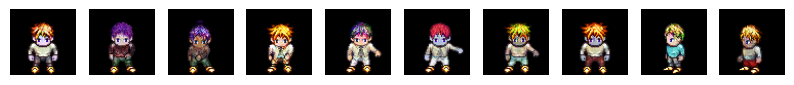

Epoch 43: Train Loss: 1277.3338, BCE: 1256.6249, KLD: 20.7089
Epoch 43: Test Loss: 1280.3585, BCE: 1260.1916, KLD: 20.1669


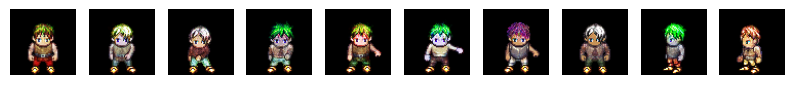

Epoch 44: Train Loss: 1277.1817, BCE: 1256.5451, KLD: 20.6366
Epoch 44: Test Loss: 1280.4246, BCE: 1260.3452, KLD: 20.0794


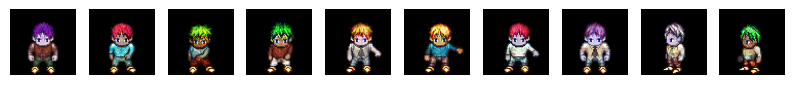

Epoch 45: Train Loss: 1276.9540, BCE: 1256.3985, KLD: 20.5554
Epoch 45: Test Loss: 1279.7375, BCE: 1259.8311, KLD: 19.9064


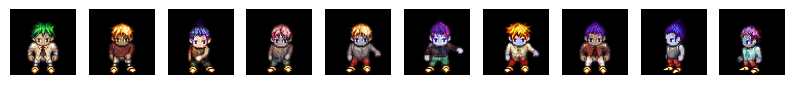

Epoch 46: Train Loss: 1276.8807, BCE: 1256.3552, KLD: 20.5254
Epoch 46: Test Loss: 1279.6088, BCE: 1259.5607, KLD: 20.0481


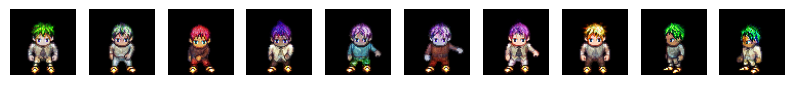

Epoch 47: Train Loss: 1276.7091, BCE: 1256.2229, KLD: 20.4862
Epoch 47: Test Loss: 1280.2793, BCE: 1259.6076, KLD: 20.6717


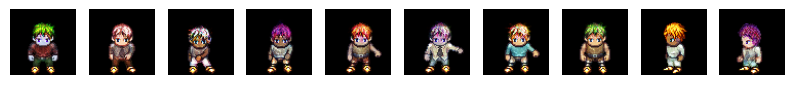

Epoch 48: Train Loss: 1276.7324, BCE: 1256.2045, KLD: 20.5280
Epoch 48: Test Loss: 1280.3237, BCE: 1259.4762, KLD: 20.8475


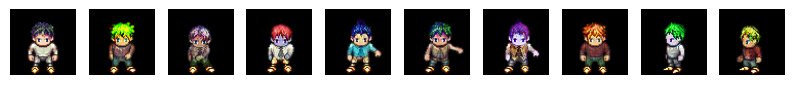

Epoch 49: Train Loss: 1276.5290, BCE: 1256.0930, KLD: 20.4360
Epoch 49: Test Loss: 1278.6291, BCE: 1258.9844, KLD: 19.6447


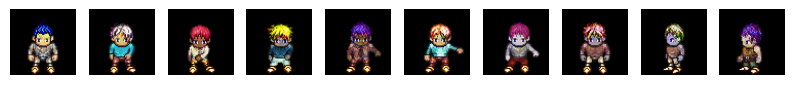

Epoch 50: Train Loss: 1276.4745, BCE: 1256.0379, KLD: 20.4366
Epoch 50: Test Loss: 1280.5542, BCE: 1259.8275, KLD: 20.7268


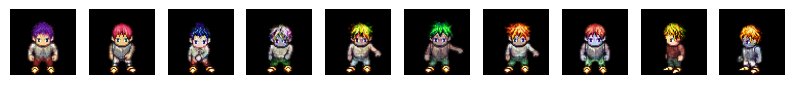

In [16]:


# Almacenar las pérdidas
train_losses = []
test_losses = []

def loss_function(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, feature_size), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())  # Divergencia KL
    return BCE + KLD, BCE, KLD

def train(epoch):
    model.train()
    total_loss = 0
    total_bce = 0
    total_kld = 0

    for batch_idx, (data, labels) in enumerate(train_loader):
        data, labels = data.to(device), labels.to(device)
        labels = one_hot(labels, num_classes)

        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data, labels)
        loss, bce, kld = loss_function(recon_batch, data, mu, logvar)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_bce += bce.item()
        total_kld += kld.item()

    avg_loss = total_loss / len(train_loader.dataset)
    avg_bce = total_bce / len(train_loader.dataset)
    avg_kld = total_kld / len(train_loader.dataset)

    train_losses.append((avg_loss, avg_bce, avg_kld))
    print(f"Epoch {epoch}: Train Loss: {avg_loss:.4f}, BCE: {avg_bce:.4f}, KLD: {avg_kld:.4f}")

def test(epoch):
    model.eval()
    total_loss = 0
    total_bce = 0
    total_kld = 0

    with torch.no_grad():
        i=0
        for data, labels in test_loader:
            data, labels = data.to(device), labels.to(device)
            labels = one_hot(labels, num_classes)

            recon_batch, mu, logvar = model(data, labels)
            loss, bce, kld = loss_function(recon_batch, data, mu, logvar)

            total_loss += loss.item()
            total_bce += bce.item()
            total_kld += kld.item()

    avg_loss = total_loss / len(test_loader.dataset)
    avg_bce = total_bce / len(test_loader.dataset)
    avg_kld = total_kld / len(test_loader.dataset)

    test_losses.append((avg_loss, avg_bce, avg_kld))
    print(f"Epoch {epoch}: Test Loss: {avg_loss:.4f}, BCE: {avg_bce:.4f}, KLD: {avg_kld:.4f}")

# Entrenamiento
for epoch in range(1, epochs + 1):
    train(epoch)
    test(epoch)
    #Dibujar entre epocas
    with torch.no_grad():
        c = torch.eye(num_classes, num_classes).to(device)[:10]
        sample = torch.randn(10, latent_size).to(device)
        sample = model.decode(sample, c).cpu()
        fig, axes = plt.subplots(1, 10, figsize=(10, 1))
        for j in range(10):
            axes[j].imshow(sample.view(10, 3, 64, 64)[j].permute(1, 2, 0).cpu().numpy())
            axes[j].axis("off")
        plt.show()




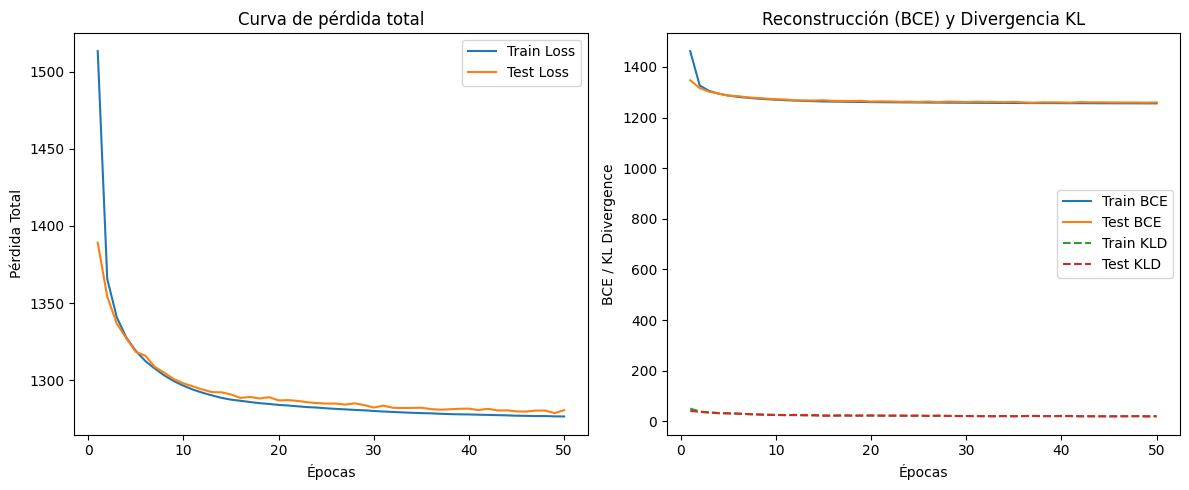

In [17]:
# Graficar curvas de pérdida
epochs_range = range(1, epochs + 1)
train_loss, train_bce, train_kld = zip(*train_losses)
test_loss, test_bce, test_kld = zip(*test_losses)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, label="Train Loss")
plt.plot(epochs_range, test_loss, label="Test Loss")
plt.xlabel("Épocas")
plt.ylabel("Pérdida Total")
plt.legend()
plt.title("Curva de pérdida total")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_bce, label="Train BCE")
plt.plot(epochs_range, test_bce, label="Test BCE")
plt.plot(epochs_range, train_kld, label="Train KLD", linestyle="dashed")
plt.plot(epochs_range, test_kld, label="Test KLD", linestyle="dashed")
plt.xlabel("Épocas")
plt.ylabel("BCE / KL Divergence")
plt.legend()
plt.title("Reconstrucción (BCE) y Divergencia KL")

plt.tight_layout()
plt.show()

tensor([11, 64, 66, 23, 10])
Consumo de VRAM: 306.41 MB
Consumo de RAM: 414.00 MB
Tiempo promedio por imagen: 0.0055 segundos


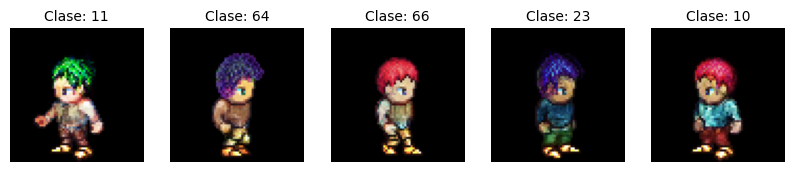

tensor([5, 5, 5, 5, 5])
Consumo de VRAM: 306.41 MB
Consumo de RAM: 414.00 MB
Tiempo promedio por imagen: 0.0013 segundos


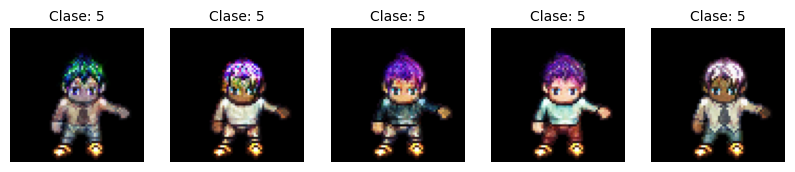

tensor([21, 21, 21, 21, 21])
Consumo de VRAM: 306.41 MB
Consumo de RAM: 414.00 MB
Tiempo promedio por imagen: 0.0020 segundos


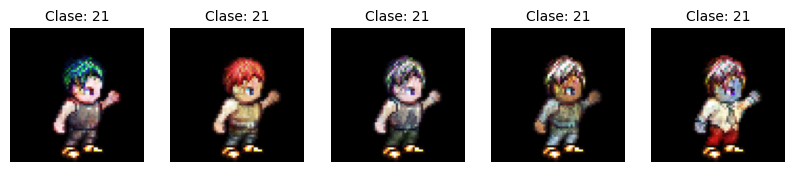

tensor([13, 13, 13, 13, 13])
Consumo de VRAM: 306.41 MB
Consumo de RAM: 414.00 MB
Tiempo promedio por imagen: 0.0022 segundos


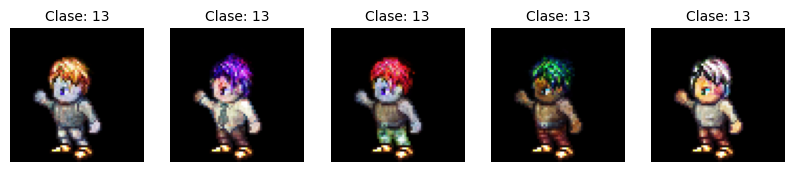

tensor([29, 29, 29, 29, 29])
Consumo de VRAM: 306.41 MB
Consumo de RAM: 414.00 MB
Tiempo promedio por imagen: 0.0013 segundos


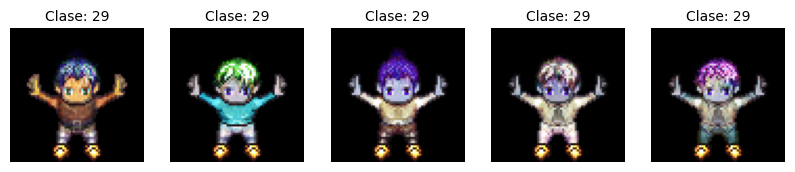

tensor([45, 45, 45, 45, 45])
Consumo de VRAM: 306.41 MB
Consumo de RAM: 414.00 MB
Tiempo promedio por imagen: 0.0032 segundos


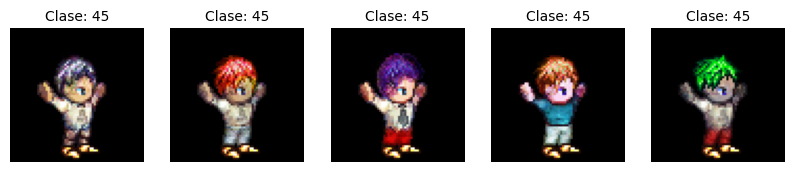

tensor([37, 37, 37, 37, 37])
Consumo de VRAM: 306.41 MB
Consumo de RAM: 414.00 MB
Tiempo promedio por imagen: 0.0012 segundos


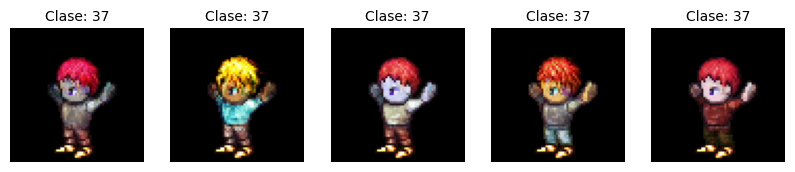

tensor([53, 53, 53, 53, 53])
Consumo de VRAM: 306.41 MB
Consumo de RAM: 414.00 MB
Tiempo promedio por imagen: 0.0013 segundos


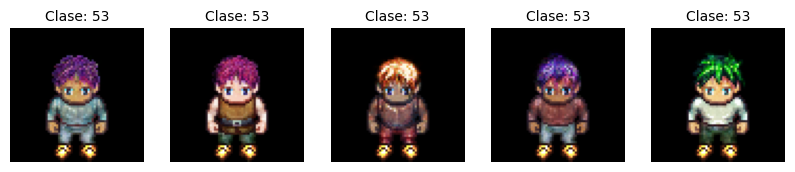

tensor([69, 69, 69, 69, 69])
Consumo de VRAM: 306.41 MB
Consumo de RAM: 414.00 MB
Tiempo promedio por imagen: 0.0013 segundos


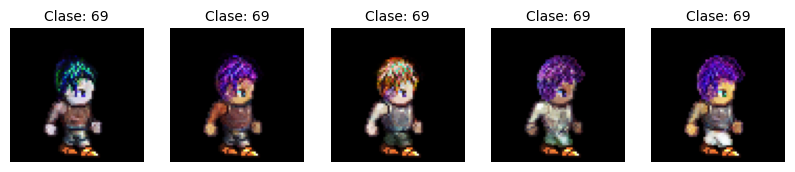

tensor([61, 61, 61, 61, 61])
Consumo de VRAM: 306.41 MB
Consumo de RAM: 414.00 MB
Tiempo promedio por imagen: 0.0014 segundos


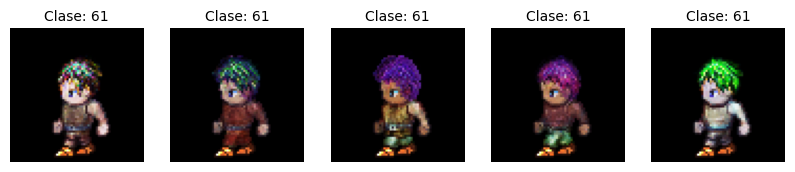

In [18]:
import time

import torch.cuda as cuda


def generate_images(model, num_samples=5,accion=None,perfil=None,movimiento=None):
    model.eval()  # Modo evaluación
   
    # Medir uso inicial de recursos
    start_time = time.time()


    with torch.no_grad():
        # Crear etiquetas aleatorias en one-hot
        if not None in [accion,perfil,movimiento]:
            perfil_grupo=['front','left','right']
            accion_grupo=['slash','spellcard','walk']
            perfiln=perfil_grupo.index(perfil)
            accionn=accion_grupo.index(accion)
            clases_list=[(accionn*3*8)+(perfiln*8)+movimiento for _ in range(num_samples)]
            clases = torch.tensor(clases_list, dtype=torch.long)
            print(clases)
        else:
            clases = torch.randint(0, num_classes, (num_samples,))
            print(clases)
        c = torch.zeros(num_samples, num_classes)
        c[range(num_samples), clases] = 1
        c = c.to(device)

        # Generar puntos aleatorios en el espacio latente
        z = torch.randn(num_samples, latent_size).to(device)

        # Decodificar para obtener imágenes
        generated_images = model.decode(z, c).cpu()
        generated_images = generated_images.view(-1, 3, 64, 64)  # RGB format

    # Medir uso final de recursos
    end_time = time.time()
    if device.type == 'cuda':
        vram_usage = cuda.memory_allocated(device) / (1024 ** 2)  # MB
        print(f"Consumo de VRAM: {vram_usage:.2f} MB")
    
    ram_usage = torch.cuda.memory_reserved(device) / (1024 ** 2)  # MB
    print(f"Consumo de RAM: {ram_usage:.2f} MB")
    # Calcular métricas
    execution_time = (end_time - start_time) / num_samples

    # Calcular métricas
    execution_time = (end_time - start_time) / num_samples


    print(f"Tiempo promedio por imagen: {execution_time:.4f} segundos")


    # Mostrar las imágenes con la clase
    fig, axes = plt.subplots(1, num_samples, figsize=(num_samples * 2, 2))
    for i in range(num_samples):
        img = generated_images[i].permute(1, 2, 0).numpy()  # Reordenar ejes
        img = (img - img.min()) / (img.max() - img.min())  # Normalizar a [0,1]
        class_label = f"Clase: {clases[i].item()}"  # Nombre de la clase

        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(class_label, fontsize=10)

    plt.show()

# Llamar a la función para generar imágenes
generate_images(model, num_samples=5)
generate_images(model, num_samples=5,perfil='front',accion='slash',movimiento=5)
generate_images(model, num_samples=5,perfil='right',accion='slash',movimiento=5)
generate_images(model, num_samples=5,perfil='left',accion='slash',movimiento=5)
generate_images(model, num_samples=5,perfil='front',accion='spellcard',movimiento=5)
generate_images(model, num_samples=5,perfil='right',accion='spellcard',movimiento=5)
generate_images(model, num_samples=5,perfil='left',accion='spellcard',movimiento=5)
generate_images(model, num_samples=5,perfil='front',accion='walk',movimiento=5)
generate_images(model, num_samples=5,perfil='right',accion='walk',movimiento=5)
generate_images(model, num_samples=5,perfil='left',accion='walk',movimiento=5)


In [19]:
#guardar modelo


import torch

# Asumiendo que 'model' es tu modelo entrenado
PATH = "pruebas modelos/VIU-TFM/modelos guardados/cvae_state_dicts.pth" # Nombre del archivo a guardar
torch.save(model.state_dict(), PATH)

PATH = "pruebas modelos/VIU-TFM/modelos guardados/cvae_completo.pth"
torch.save(model, PATH)



## HVAE

In [22]:
# Hiperparámetros
batch_size = 32
latent_size = 20
latent_size2 = latent_size
epochs = 50
feature_size = img_width * img_height * 3  # 64x64x3

# Definición del modelo HVAE
class HVAE(nn.Module):
    def __init__(self, feature_size, latent_size):
        super(HVAE, self).__init__()
        self.feature_size = feature_size
        self.latent_size = latent_size

        # Primera capa latente (z1) -> Representa información general
        self.fc1 = nn.Linear(feature_size, 512)
        self.fc21 = nn.Linear(512, latent_size // 2)  # Mu de z1
        self.fc22 = nn.Linear(512, latent_size // 2)  # LogVar de z1

        # Segunda capa latente (z2) -> Representa detalles más finos
        self.fc3 = nn.Linear(latent_size // 2, 256)
        self.fc31 = nn.Linear(256, latent_size // 2)  # Mu de z2
        self.fc32 = nn.Linear(256, latent_size // 2)  # LogVar de z2

        # Decodificador
        self.fc4 = nn.Linear(latent_size // 2, 256)  # Decodifica z2
        self.fc5 = nn.Linear(256, latent_size // 2)  # Reconstrucción de z1
        self.fc6 = nn.Linear(latent_size, 512)  # Decodifica z1 + z1_rec
        self.fc7 = nn.Linear(512, feature_size)  # Genera la imagen final

        self.elu = nn.ELU()
        self.sigmoid = nn.Sigmoid()

    def encode(self, x):
        """ Codifica la imagen en z1 y luego en z2 """
        x = x.view(-1, self.feature_size)
        h1 = self.elu(self.fc1(x))
        mu1, logvar1 = self.fc21(h1), self.fc22(h1)
        z1 = self.reparameterize(mu1, logvar1)

        h3 = self.elu(self.fc3(z1))
        mu2, logvar2 = self.fc31(h3), self.fc32(h3)
        z2 = self.reparameterize(mu2, logvar2)

        return z1, mu1, logvar1, z2, mu2, logvar2

    def reparameterize(self, mu, logvar):
        """ Muestreo usando la reparametrización de Kingma y Welling """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z1, z2):
        """ Decodifica la imagen desde las variables latentes """
        h4 = self.elu(self.fc4(z2))
        z1_decoded = self.fc5(h4)  # Reconstrucción de z1

        z_concat = torch.cat([z1, z1_decoded], dim=1)  # Concatenar z1 original + reconstruido

        h6 = self.elu(self.fc6(z_concat))
        return self.sigmoid(self.fc7(h6))  # Imagen reconstruida

    def forward(self, x):
        """ Pasa la imagen por el modelo y devuelve la reconstrucción """
        z1, mu1, logvar1, z2, mu2, logvar2 = self.encode(x)
        recon_x = self.decode(z1, z2)
        return recon_x, mu1, logvar1, mu2, logvar2


# Crear el modelo
model = HVAE(feature_size, latent_size).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Epoch 1: Train Loss: 1548.3675, BCE: 1507.7657, KLD1: 38.6287, KLD2: 1.9731
Epoch 1: Test Loss: 1443.8147, BCE: 1406.2704, KLD1: 35.6076, KLD2: 1.9367


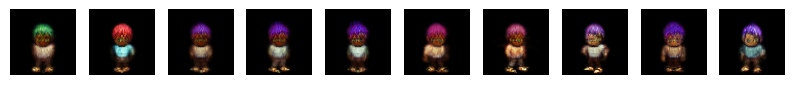

Epoch 2: Train Loss: 1415.2811, BCE: 1378.5086, KLD1: 34.8799, KLD2: 1.8926
Epoch 2: Test Loss: 1401.9606, BCE: 1365.5800, KLD1: 34.4411, KLD2: 1.9395


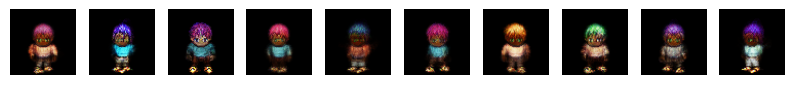

Epoch 3: Train Loss: 1387.6680, BCE: 1352.1401, KLD1: 33.6021, KLD2: 1.9258
Epoch 3: Test Loss: 1382.8339, BCE: 1347.4712, KLD1: 33.4030, KLD2: 1.9598


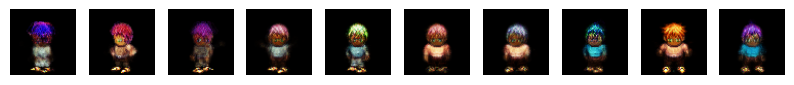

Epoch 4: Train Loss: 1373.7297, BCE: 1339.0813, KLD1: 32.7044, KLD2: 1.9440
Epoch 4: Test Loss: 1373.2974, BCE: 1338.9071, KLD1: 32.4444, KLD2: 1.9460


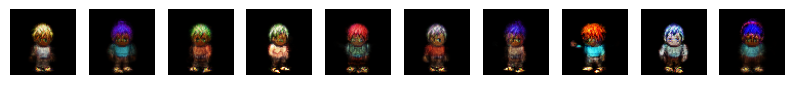

Epoch 5: Train Loss: 1364.4145, BCE: 1330.2995, KLD1: 32.1629, KLD2: 1.9521
Epoch 5: Test Loss: 1364.0063, BCE: 1330.5314, KLD1: 31.5058, KLD2: 1.9691


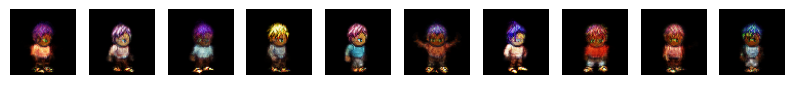

Epoch 6: Train Loss: 1358.2848, BCE: 1324.5962, KLD1: 31.7202, KLD2: 1.9683
Epoch 6: Test Loss: 1361.8684, BCE: 1327.8180, KLD1: 32.0997, KLD2: 1.9506


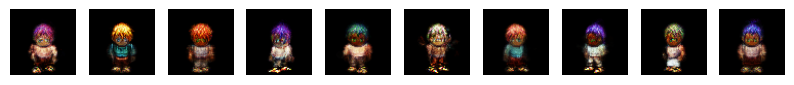

Epoch 7: Train Loss: 1353.4576, BCE: 1320.1606, KLD1: 31.3198, KLD2: 1.9773
Epoch 7: Test Loss: 1355.1885, BCE: 1321.8681, KLD1: 31.3198, KLD2: 2.0007


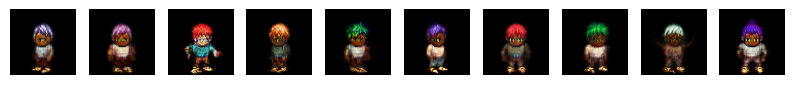

Epoch 8: Train Loss: 1349.5970, BCE: 1316.5393, KLD1: 31.0721, KLD2: 1.9855
Epoch 8: Test Loss: 1353.3384, BCE: 1320.4528, KLD1: 30.9273, KLD2: 1.9582


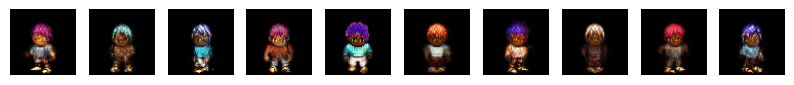

Epoch 9: Train Loss: 1346.7577, BCE: 1313.8262, KLD1: 30.9277, KLD2: 2.0038
Epoch 9: Test Loss: 1352.2045, BCE: 1318.2948, KLD1: 31.8749, KLD2: 2.0348


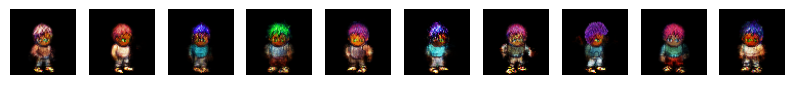

Epoch 10: Train Loss: 1344.0588, BCE: 1311.2272, KLD1: 30.8091, KLD2: 2.0225
Epoch 10: Test Loss: 1344.4164, BCE: 1312.0252, KLD1: 30.3504, KLD2: 2.0408


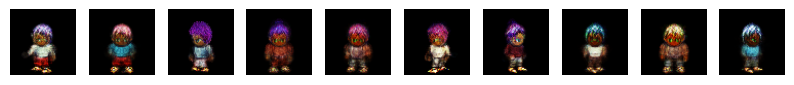

Epoch 11: Train Loss: 1341.3793, BCE: 1308.5979, KLD1: 30.7374, KLD2: 2.0440
Epoch 11: Test Loss: 1342.5926, BCE: 1310.0546, KLD1: 30.5392, KLD2: 1.9988


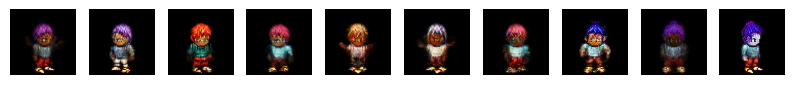

Epoch 12: Train Loss: 1339.3987, BCE: 1306.6441, KLD1: 30.6861, KLD2: 2.0685
Epoch 12: Test Loss: 1341.0298, BCE: 1308.3997, KLD1: 30.5532, KLD2: 2.0769


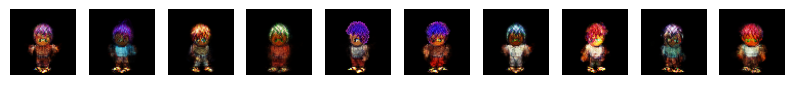

Epoch 13: Train Loss: 1337.4216, BCE: 1304.7078, KLD1: 30.6294, KLD2: 2.0844
Epoch 13: Test Loss: 1340.3200, BCE: 1307.2491, KLD1: 30.9555, KLD2: 2.1154


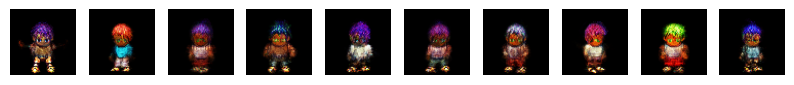

Epoch 14: Train Loss: 1335.6492, BCE: 1303.0072, KLD1: 30.5384, KLD2: 2.1036
Epoch 14: Test Loss: 1336.3009, BCE: 1303.2323, KLD1: 30.9873, KLD2: 2.0813


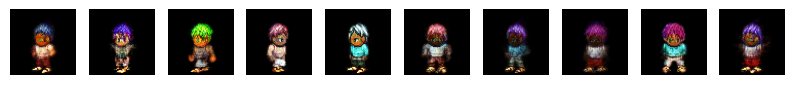

Epoch 15: Train Loss: 1334.5175, BCE: 1301.9052, KLD1: 30.5016, KLD2: 2.1107
Epoch 15: Test Loss: 1343.4820, BCE: 1310.6460, KLD1: 30.7774, KLD2: 2.0586


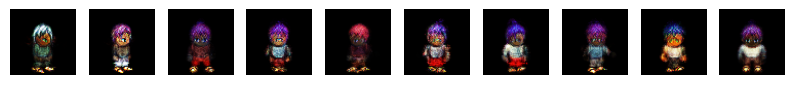

Epoch 16: Train Loss: 1333.2418, BCE: 1300.6401, KLD1: 30.4713, KLD2: 2.1304
Epoch 16: Test Loss: 1338.2707, BCE: 1305.5627, KLD1: 30.5679, KLD2: 2.1401


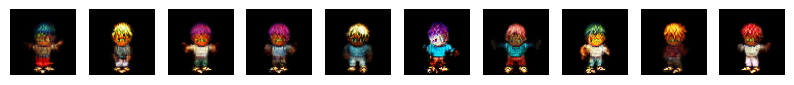

Epoch 17: Train Loss: 1331.7748, BCE: 1299.2392, KLD1: 30.4015, KLD2: 2.1340
Epoch 17: Test Loss: 1335.1062, BCE: 1302.1857, KLD1: 30.8573, KLD2: 2.0632


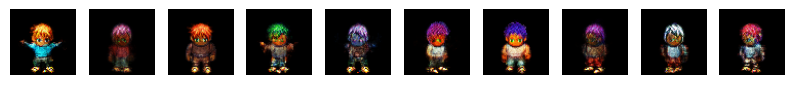

Epoch 18: Train Loss: 1331.1177, BCE: 1298.6244, KLD1: 30.3399, KLD2: 2.1534
Epoch 18: Test Loss: 1333.4102, BCE: 1301.2432, KLD1: 30.0437, KLD2: 2.1234


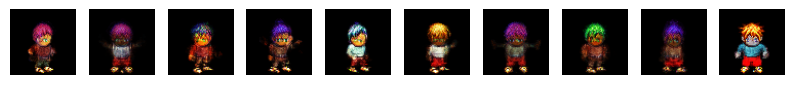

Epoch 19: Train Loss: 1329.8680, BCE: 1297.3948, KLD1: 30.3227, KLD2: 2.1505
Epoch 19: Test Loss: 1332.2480, BCE: 1299.2411, KLD1: 30.8653, KLD2: 2.1417


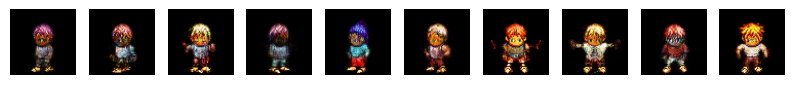

Epoch 20: Train Loss: 1328.9970, BCE: 1296.5508, KLD1: 30.2885, KLD2: 2.1577
Epoch 20: Test Loss: 1331.3527, BCE: 1298.4376, KLD1: 30.7794, KLD2: 2.1357


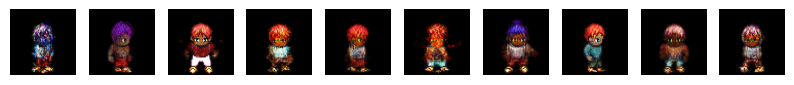

Epoch 21: Train Loss: 1328.2966, BCE: 1295.8739, KLD1: 30.2498, KLD2: 2.1729
Epoch 21: Test Loss: 1335.3725, BCE: 1302.9428, KLD1: 30.2648, KLD2: 2.1649


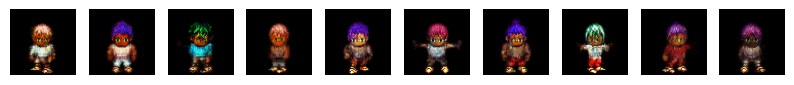

Epoch 22: Train Loss: 1327.3800, BCE: 1295.0060, KLD1: 30.2040, KLD2: 2.1699
Epoch 22: Test Loss: 1329.3233, BCE: 1297.3157, KLD1: 29.8781, KLD2: 2.1294


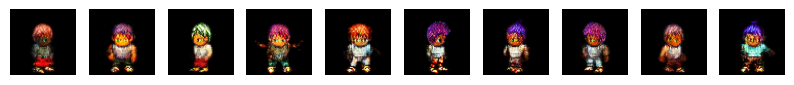

Epoch 23: Train Loss: 1326.8512, BCE: 1294.5066, KLD1: 30.1659, KLD2: 2.1787
Epoch 23: Test Loss: 1328.3751, BCE: 1295.9588, KLD1: 30.2346, KLD2: 2.1817


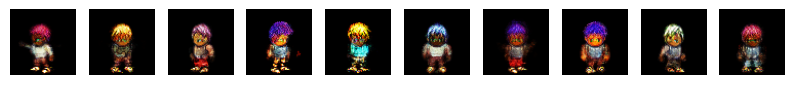

Epoch 24: Train Loss: 1326.2198, BCE: 1293.9074, KLD1: 30.1275, KLD2: 2.1849
Epoch 24: Test Loss: 1326.5014, BCE: 1293.4609, KLD1: 30.8495, KLD2: 2.1910


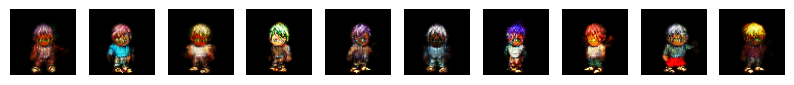

Epoch 25: Train Loss: 1325.7129, BCE: 1293.4282, KLD1: 30.0920, KLD2: 2.1927
Epoch 25: Test Loss: 1329.1471, BCE: 1296.0725, KLD1: 30.8655, KLD2: 2.2091


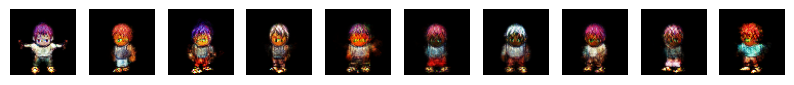

Epoch 26: Train Loss: 1324.7900, BCE: 1292.5232, KLD1: 30.0788, KLD2: 2.1879
Epoch 26: Test Loss: 1326.7225, BCE: 1294.8160, KLD1: 29.7501, KLD2: 2.1564


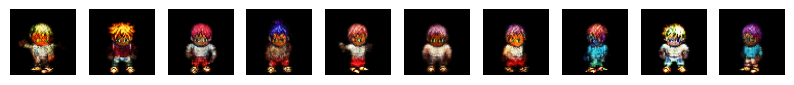

Epoch 27: Train Loss: 1324.5348, BCE: 1292.3030, KLD1: 30.0350, KLD2: 2.1968
Epoch 27: Test Loss: 1330.2795, BCE: 1297.8915, KLD1: 30.1793, KLD2: 2.2087


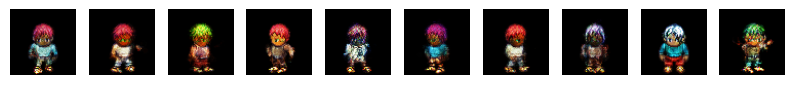

Epoch 28: Train Loss: 1323.9187, BCE: 1291.6955, KLD1: 30.0225, KLD2: 2.2007
Epoch 28: Test Loss: 1328.2395, BCE: 1296.4202, KLD1: 29.5914, KLD2: 2.2279


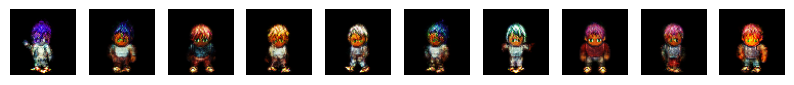

Epoch 29: Train Loss: 1323.3202, BCE: 1291.1570, KLD1: 29.9582, KLD2: 2.2049
Epoch 29: Test Loss: 1326.0767, BCE: 1293.7636, KLD1: 30.0970, KLD2: 2.2160


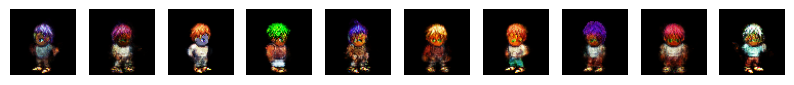

Epoch 30: Train Loss: 1323.1345, BCE: 1290.9652, KLD1: 29.9564, KLD2: 2.2128
Epoch 30: Test Loss: 1325.9588, BCE: 1294.1797, KLD1: 29.5421, KLD2: 2.2370


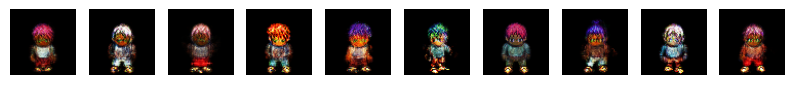

Epoch 31: Train Loss: 1322.6124, BCE: 1290.4830, KLD1: 29.9314, KLD2: 2.1980
Epoch 31: Test Loss: 1326.0189, BCE: 1293.5887, KLD1: 30.2410, KLD2: 2.1893


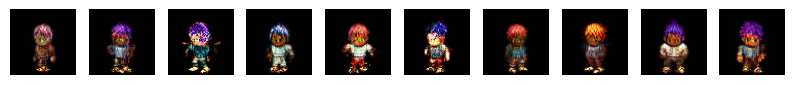

Epoch 32: Train Loss: 1322.0584, BCE: 1289.9202, KLD1: 29.9244, KLD2: 2.2138
Epoch 32: Test Loss: 1327.9591, BCE: 1294.9938, KLD1: 30.7911, KLD2: 2.1742


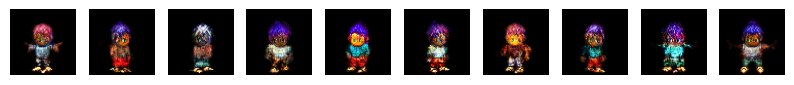

Epoch 33: Train Loss: 1321.6688, BCE: 1289.5417, KLD1: 29.9143, KLD2: 2.2129
Epoch 33: Test Loss: 1323.8586, BCE: 1292.1513, KLD1: 29.4944, KLD2: 2.2130


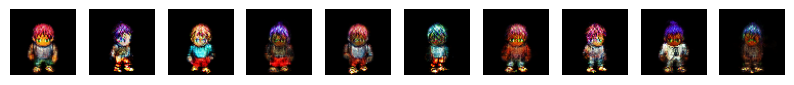

Epoch 34: Train Loss: 1321.3327, BCE: 1289.2455, KLD1: 29.8663, KLD2: 2.2209
Epoch 34: Test Loss: 1325.7114, BCE: 1294.0255, KLD1: 29.4825, KLD2: 2.2034


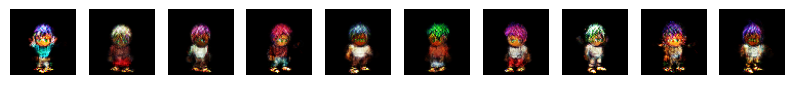

Epoch 35: Train Loss: 1320.9038, BCE: 1288.8266, KLD1: 29.8554, KLD2: 2.2218
Epoch 35: Test Loss: 1323.3502, BCE: 1290.9033, KLD1: 30.2224, KLD2: 2.2245


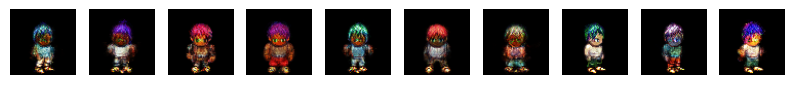

Epoch 36: Train Loss: 1320.5465, BCE: 1288.4974, KLD1: 29.8196, KLD2: 2.2296
Epoch 36: Test Loss: 1326.9004, BCE: 1294.2321, KLD1: 30.4045, KLD2: 2.2638


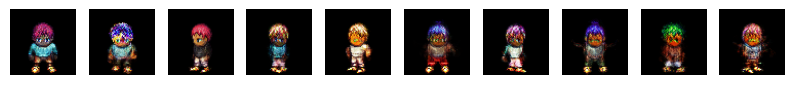

Epoch 37: Train Loss: 1320.4047, BCE: 1288.3711, KLD1: 29.8039, KLD2: 2.2296
Epoch 37: Test Loss: 1322.3159, BCE: 1289.4839, KLD1: 30.5894, KLD2: 2.2427


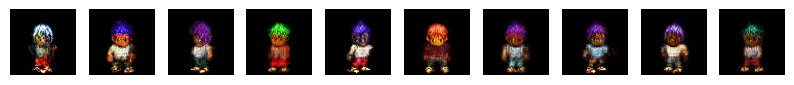

Epoch 38: Train Loss: 1319.8102, BCE: 1287.7771, KLD1: 29.7977, KLD2: 2.2353
Epoch 38: Test Loss: 1321.9198, BCE: 1289.6317, KLD1: 30.1104, KLD2: 2.1776


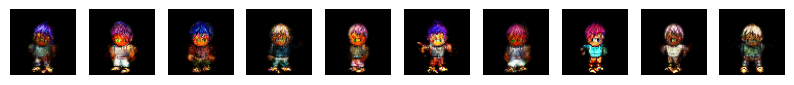

Epoch 39: Train Loss: 1319.5502, BCE: 1287.5336, KLD1: 29.7870, KLD2: 2.2295
Epoch 39: Test Loss: 1320.2472, BCE: 1288.2304, KLD1: 29.8407, KLD2: 2.1761


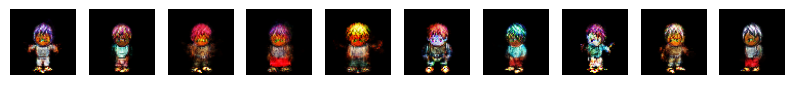

Epoch 40: Train Loss: 1319.2475, BCE: 1287.2313, KLD1: 29.7766, KLD2: 2.2395
Epoch 40: Test Loss: 1323.3069, BCE: 1291.2876, KLD1: 29.7865, KLD2: 2.2328


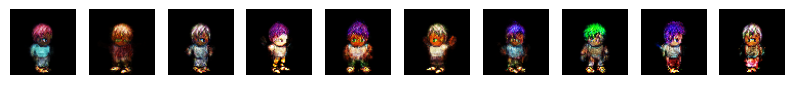

Epoch 41: Train Loss: 1318.9993, BCE: 1286.9939, KLD1: 29.7593, KLD2: 2.2460
Epoch 41: Test Loss: 1322.2989, BCE: 1290.4592, KLD1: 29.6376, KLD2: 2.2021


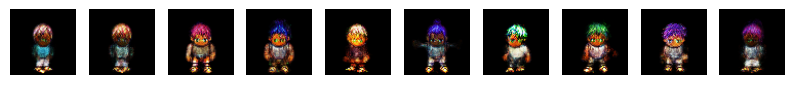

Epoch 42: Train Loss: 1318.8558, BCE: 1286.8313, KLD1: 29.7812, KLD2: 2.2433
Epoch 42: Test Loss: 1323.4942, BCE: 1291.2125, KLD1: 30.0609, KLD2: 2.2207


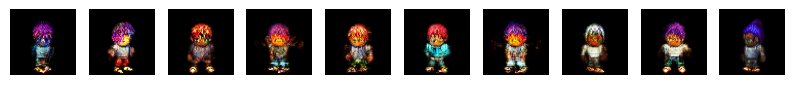

Epoch 43: Train Loss: 1318.5167, BCE: 1286.5097, KLD1: 29.7638, KLD2: 2.2432
Epoch 43: Test Loss: 1321.6405, BCE: 1290.0297, KLD1: 29.3443, KLD2: 2.2665


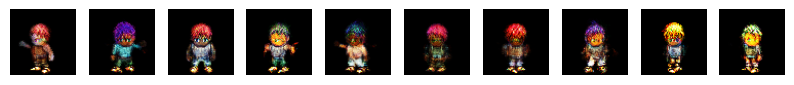

Epoch 44: Train Loss: 1318.2505, BCE: 1286.2619, KLD1: 29.7297, KLD2: 2.2588
Epoch 44: Test Loss: 1321.4588, BCE: 1289.6120, KLD1: 29.5790, KLD2: 2.2678


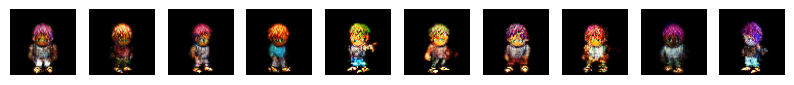

Epoch 45: Train Loss: 1318.2170, BCE: 1286.2453, KLD1: 29.7176, KLD2: 2.2541
Epoch 45: Test Loss: 1322.6112, BCE: 1290.8754, KLD1: 29.5182, KLD2: 2.2177


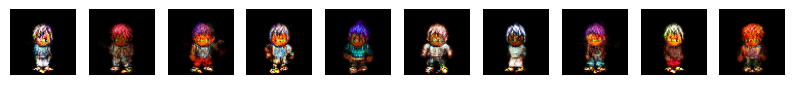

Epoch 46: Train Loss: 1317.4548, BCE: 1285.4936, KLD1: 29.7050, KLD2: 2.2561
Epoch 46: Test Loss: 1319.5054, BCE: 1287.5852, KLD1: 29.6799, KLD2: 2.2404


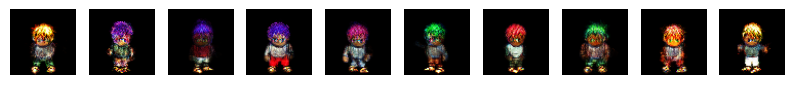

Epoch 47: Train Loss: 1317.5288, BCE: 1285.5809, KLD1: 29.6937, KLD2: 2.2542
Epoch 47: Test Loss: 1318.3858, BCE: 1286.9554, KLD1: 29.1622, KLD2: 2.2682


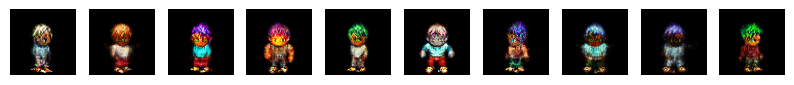

Epoch 48: Train Loss: 1317.3562, BCE: 1285.4112, KLD1: 29.6809, KLD2: 2.2642
Epoch 48: Test Loss: 1328.3822, BCE: 1296.9325, KLD1: 29.1721, KLD2: 2.2776


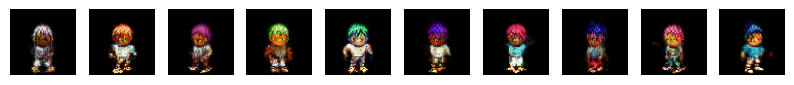

Epoch 49: Train Loss: 1316.9408, BCE: 1285.0204, KLD1: 29.6583, KLD2: 2.2621
Epoch 49: Test Loss: 1319.5797, BCE: 1287.1120, KLD1: 30.2202, KLD2: 2.2475


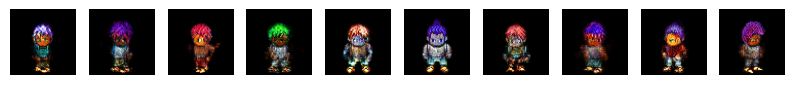

Epoch 50: Train Loss: 1316.8148, BCE: 1284.8950, KLD1: 29.6588, KLD2: 2.2609
Epoch 50: Test Loss: 1320.1521, BCE: 1289.0947, KLD1: 28.8385, KLD2: 2.2189


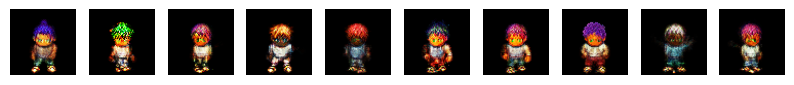

In [23]:

# Almacenar las pérdidas
train_losses = []
test_losses = []

def loss_function_hvae(recon_x, x, mu1, logvar1, mu2, logvar2):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, feature_size), reduction='sum')
    
    # KL divergencia para z1
    KLD1 = -0.5 * torch.sum(1 + logvar1 - mu1.pow(2) - logvar1.exp())  
    
    # KL divergencia para z2
    KLD2 = -0.5 * torch.sum(1 + logvar2 - mu2.pow(2) - logvar2.exp())  
    
    return BCE + KLD1 + KLD2, BCE, KLD1, KLD2
def train(epoch):
    model.train()
    total_loss = 0
    total_bce = 0
    total_kld1 = 0
    total_kld2 = 0

    for batch_idx, (data, labels) in enumerate(train_loader):
        data = data.to(device)
        data = data.view(-1, feature_size)  # Aplanar imágenes a vectores
        optimizer.zero_grad()
        recon_batch, mu1, logvar1, mu2, logvar2 = model(data)
        loss, bce, kld1, kld2 = loss_function_hvae(recon_batch, data, mu1, logvar1, mu2, logvar2)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_bce += bce.item()
        total_kld1 += kld1.item()
        total_kld2 += kld2.item()

    avg_loss = total_loss / len(train_loader.dataset)
    avg_bce = total_bce / len(train_loader.dataset)
    avg_kld1 = total_kld1 / len(train_loader.dataset)
    avg_kld2 = total_kld2 / len(train_loader.dataset)

    train_losses.append((avg_loss, avg_bce, avg_kld1, avg_kld2))
    print(f"Epoch {epoch}: Train Loss: {avg_loss:.4f}, BCE: {avg_bce:.4f}, KLD1: {avg_kld1:.4f}, KLD2: {avg_kld2:.4f}")

def test(epoch):
    model.eval()
    total_loss = 0
    total_bce = 0
    total_kld1 = 0
    total_kld2 = 0

    with torch.no_grad():
        for (data, _) in test_loader:
            data = data.to(device)
            recon_batch, mu1, logvar1, mu2, logvar2 = model(data)
            loss, bce, kld1, kld2 = loss_function_hvae(recon_batch, data, mu1, logvar1, mu2, logvar2)

            total_loss += loss.item()
            total_bce += bce.item()
            total_kld1 += kld1.item()
            total_kld2 += kld2.item()

    avg_loss = total_loss / len(test_loader.dataset)
    avg_bce = total_bce / len(test_loader.dataset)
    avg_kld1 = total_kld1 / len(test_loader.dataset)
    avg_kld2 = total_kld2 / len(test_loader.dataset)

    test_losses.append((avg_loss, avg_bce, avg_kld1, avg_kld2))
    print(f"Epoch {epoch}: Test Loss: {avg_loss:.4f}, BCE: {avg_bce:.4f}, KLD1: {avg_kld1:.4f}, KLD2: {avg_kld2:.4f}")


# Entrenamiento
for epoch in range(1, epochs + 1):
    train(epoch)
    test(epoch)
    #Dibujar entre epocas
    with torch.no_grad():
        sample_z1 = torch.randn(10, latent_size // 2).to(device)
        sample_z2 = torch.randn(10, latent_size // 2).to(device)
        sample = model.decode(sample_z1,sample_z2).cpu()
        fig, axes = plt.subplots(1, 10, figsize=(10, 1))
        for j in range(10):
            axes[j].imshow(sample.view(10, 3, 64, 64)[j].permute(1, 2, 0).cpu().numpy())
            axes[j].axis("off")
        plt.show()


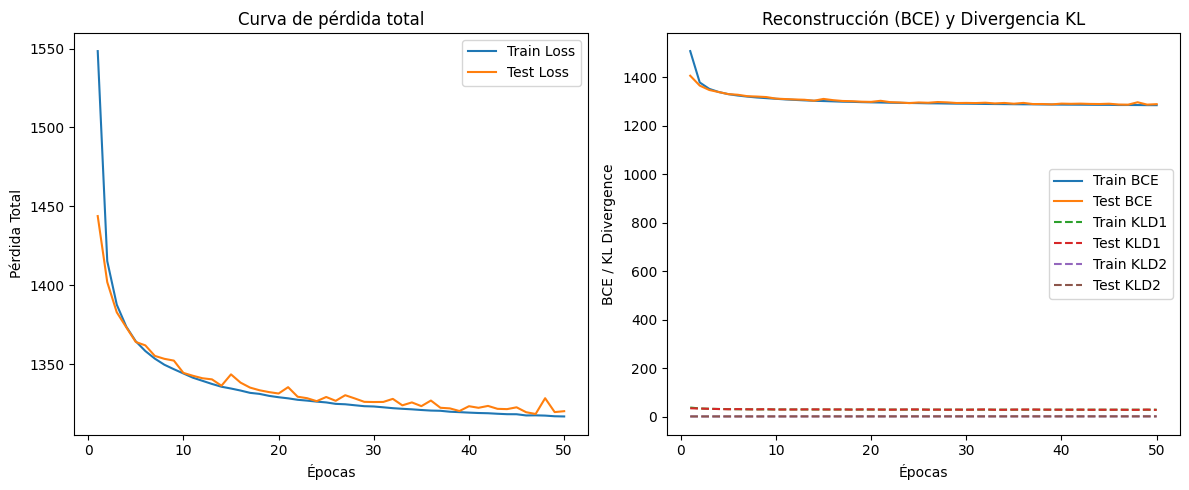

In [24]:
# Graficar curvas de pérdida
epochs_range = range(1, epochs + 1)
train_loss, train_bce, train_kld1,train_kld2 = zip(*train_losses)
test_loss, test_bce, test_kld1,test_kld2 = zip(*test_losses)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, label="Train Loss")
plt.plot(epochs_range, test_loss, label="Test Loss")
plt.xlabel("Épocas")
plt.ylabel("Pérdida Total")
plt.legend()
plt.title("Curva de pérdida total")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_bce, label="Train BCE")
plt.plot(epochs_range, test_bce, label="Test BCE")
plt.plot(epochs_range, train_kld1, label="Train KLD1", linestyle="dashed")
plt.plot(epochs_range, test_kld1, label="Test KLD1", linestyle="dashed")
plt.plot(epochs_range, train_kld2, label="Train KLD2", linestyle="dashed")
plt.plot(epochs_range, test_kld2, label="Test KLD2", linestyle="dashed")
plt.xlabel("Épocas")
plt.ylabel("BCE / KL Divergence")
plt.legend()
plt.title("Reconstrucción (BCE) y Divergencia KL")

plt.tight_layout()
plt.show()

Consumo de VRAM: 305.34 MB
Consumo de RAM: 414.00 MB
Tiempo promedio por imagen: 0.0011 segundos


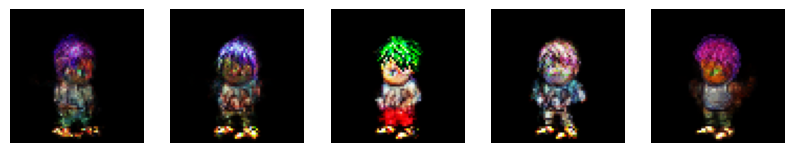

In [25]:
import time



def generate_images_HVAE(model, num_samples=5):
    model.eval()  # Modo evaluación
   
    # Medir uso inicial de recursos
    start_time = time.time()

    with torch.no_grad():
        # Generar puntos aleatorios en el espacio latente
        z1 = torch.randn(num_samples, latent_size // 2).to(device)
        z2 = torch.randn(num_samples, latent_size // 2).to(device)
        # Decodificar para obtener imágenes
        generated_images = model.decode(z1,z2).cpu()
        generated_images = generated_images.view(-1, 3, 64, 64)  # RGB format

    # Medir uso final de recursos
    end_time = time.time()
    if device.type == 'cuda':
        vram_usage = cuda.memory_allocated(device) / (1024 ** 2)  # MB
        print(f"Consumo de VRAM: {vram_usage:.2f} MB")
    
    ram_usage = torch.cuda.memory_reserved(device) / (1024 ** 2)  # MB
    print(f"Consumo de RAM: {ram_usage:.2f} MB")
    # Calcular métricas
    execution_time = (end_time - start_time) / num_samples
    # Calcular métricas
    execution_time = (end_time - start_time) / num_samples


    print(f"Tiempo promedio por imagen: {execution_time:.4f} segundos")

    # Mostrar las imágenes con la clase
    fig, axes = plt.subplots(1, num_samples, figsize=(num_samples * 2, 2))
    for i in range(num_samples):
        img = generated_images[i].permute(1, 2, 0).numpy()  # Reordenar ejes
        img = (img - img.min()) / (img.max() - img.min())  # Normalizar a [0,1]
        axes[i].imshow(img)
        axes[i].axis('off')

    plt.show()

# Llamar a la función para generar imágenes
generate_images_HVAE(model, num_samples=5)

In [26]:
#guardar modelo


import torch

# Asumiendo que 'model' es tu modelo entrenado
PATH = "pruebas modelos/VIU-TFM/modelos guardados/hvae_state_dicts.pth" # Nombre del archivo a guardar
torch.save(model.state_dict(), PATH)

PATH = "pruebas modelos/VIU-TFM/modelos guardados/hvae_completo.pth"
torch.save(model, PATH)